In [304]:
import sys
import os

sys.path.append(os.path.abspath("../../.."))

from core.split_samples import get_splited_data
from scipy.linalg import LinAlgError
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import GroupShuffleSplit, GroupKFold

from sklearn.metrics import classification_report, precision_score, recall_score, f1_score
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import Precision, Recall
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.models import Sequential


import matplotlib.pyplot as plt
import pandas as pd


import numpy as np


import seaborn as sns
import pickle

# **Fase exploratória**

##     **Exploratory Analysis**

### **Etapa 1: Análise Inicial e Preparação**

- Dados a Utilizar: DataFrame Total.
- Objetivo Principal: Garantir a saúde, integridade e o entendimento básico dos dados brutos antes de qualquer divisão.


### 1.1 Carregando os dados

In [305]:
data = pd.read_excel('../../../data/datasets/base_vertical/intermediate/HS_agregado_sem_cod_20windows_normal_sopro_binary_kalman.xlsx')
data = data.drop(columns=['window_id'])

data

,Heart Sound ID,freq_mean,centro_x_mean,centro_y_mean,raio_medio_mean,raio_std_mean,raio_max_mean,raio_min_mean,simetria_x_mean,simetria_y_mean,...,lpc_8,lpc_9,lpc_10,autocorr_lag_1,autocorr_lag_2,autocorr_lag_3,has_trapping,Gender,Heart Sound Type,Location
0,F_N_A,38.947088,0.000138,-0.001044,0.018642,0.028805,0.263116,0.000359,0.018708,0.018392,...,1.713229,-1.044067,0.305385,1.345752,1.076504,0.715913,1,F,Normal,Apex
1,F_N_A,56.122449,-0.000167,0.000062,0.013477,0.014198,0.104961,0.000235,0.013909,0.013916,...,1.729227,-1.230102,0.477753,0.795063,0.554252,0.230146,1,F,Normal,Apex
2,F_N_A,56.293403,0.000058,-0.000161,0.014460,0.018392,0.131593,0.000241,0.015047,0.015000,...,1.743406,-1.199633,0.449937,0.880420,0.631777,0.288556,1,F,Normal,Apex
3,F_N_A,55.020492,-0.000019,0.000076,0.016932,0.019212,0.131481,0.000268,0.017100,0.017092,...,1.731451,-1.166385,0.434568,0.886530,0.632031,0.281664,1,F,Normal,Apex
4,F_N_A,55.631510,-0.000081,-0.000132,0.017223,0.020330,0.150575,0.000277,0.017959,0.017934,...,1.701095,-1.182036,0.453586,0.768554,0.530060,0.207630,1,F,Normal,Apex
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
963,M_S4_LUSB,68.496094,0.000448,0.000030,0.013175,0.017431,0.119670,0.000238,0.013284,0.013007,...,1.397545,-0.899361,0.305113,0.566057,0.247114,-0.140051,1,M,Sopro Cardíaco,LUSB
964,M_S4_LUSB,73.806424,0.000084,-0.000087,0.010320,0.013823,0.098442,0.000189,0.010527,0.010526,...,1.368087,-0.890281,0.295327,0.531063,0.225153,-0.145009,1,M,Sopro Cardíaco,LUSB
965,M_S4_LUSB,68.779481,-0.000011,0.000014,0.010745,0.014075,0.109291,0.000204,0.010903,0.010654,...,1.381223,-0.890641,0.296470,0.414443,0.178112,-0.107803,1,M,Sopro Cardíaco,LUSB
966,M_S4_LUSB,74.932065,-0.000081,0.000036,0.011884,0.015942,0.105043,0.000181,0.012153,0.011880,...,1.319910,-0.869489,0.288313,0.450928,0.180372,-0.144995,1,M,Sopro Cardíaco,LUSB


### 1.2 Inspeção Estrutural
Verificar o número de linhas, colunas, e os tipos de dados de cada coluna. Procurar por colunas que deveriam ser numéricas mas estão como object (texto).

In [306]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 968 entries, 0 to 967
Data columns (total 100 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Heart Sound ID              968 non-null    object 
 1   freq_mean                   968 non-null    float64
 2   centro_x_mean               968 non-null    float64
 3   centro_y_mean               968 non-null    float64
 4   raio_medio_mean             968 non-null    float64
 5   raio_std_mean               968 non-null    float64
 6   raio_max_mean               968 non-null    float64
 7   raio_min_mean               968 non-null    float64
 8   simetria_x_mean             968 non-null    float64
 9   simetria_y_mean             968 non-null    float64
 10  densidade_nucleo_mean       968 non-null    float64
 11  comprimento_curva_mean      968 non-null    float64
 12  variacao_curvatura_mean     968 non-null    float64
 13  mudanca_media_direcao_mean  968 no

In [307]:
len(data.columns)

100

In [308]:
data.isnull().sum()

Heart Sound ID      0
freq_mean           0
centro_x_mean       0
centro_y_mean       0
raio_medio_mean     0
                   ..
autocorr_lag_3      0
has_trapping        0
Gender              0
Heart Sound Type    0
Location            0
Length: 100, dtype: int64

### 1.3 Análise Descritiva

Calcular estatísticas básicas (média, desvio padrão, mínimo, máximo, quartis) para todas as colunas numéricas. Isso ajuda a identificar escalas muito diferentes entre as features, o que confirma a necessidade de normalização mais tarde.

In [309]:
data.describe()

,freq_mean,centro_x_mean,centro_y_mean,raio_medio_mean,raio_std_mean,raio_max_mean,raio_min_mean,simetria_x_mean,simetria_y_mean,densidade_nucleo_mean,...,lpc_5,lpc_6,lpc_7,lpc_8,lpc_9,lpc_10,autocorr_lag_1,autocorr_lag_2,autocorr_lag_3,has_trapping
count,968.000000,968.000000,968.000000,968.000000,968.000000,968.000000,968.000000,968.000000,968.000000,968.000000,...,968.000000,968.000000,968.000000,968.000000,968.000000,968.000000,968.000000,968.000000,968.000000,968.000000
mean,55.868536,-0.000014,0.000015,0.011782,0.011673,0.079018,0.000208,0.011660,0.011576,0.731524,...,-2.158557,2.044311,-1.807912,1.449802,-0.877246,0.321255,0.536148,0.398811,0.219421,0.891529
std,10.202381,0.000227,0.000184,0.007082,0.006561,0.046391,0.000144,0.006978,0.006897,0.145621,...,0.764601,0.686846,0.566735,0.415206,0.248294,0.082057,0.652263,0.557636,0.436932,0.311135
min,32.175926,-0.002871,-0.001044,0.002382,0.002319,0.013773,0.000035,0.002316,0.002315,0.349781,...,-5.379188,0.929234,-4.250719,0.659612,-1.648991,0.075714,0.020261,0.011209,-0.296855,0.000000
25%,49.054974,-0.000056,-0.000043,0.006361,0.006570,0.046839,0.000103,0.006321,0.006311,0.626675,...,-2.479971,1.592455,-2.167930,1.120645,-1.083431,0.273421,0.136163,0.089650,0.013744,1.000000
50%,56.225198,-0.000004,0.000004,0.010848,0.010912,0.069607,0.000181,0.010724,0.010626,0.750604,...,-2.022023,1.868547,-1.695070,1.400456,-0.876651,0.327188,0.394436,0.247171,0.084347,1.000000
75%,61.548869,0.000047,0.000057,0.015015,0.015488,0.104399,0.000261,0.014825,0.014675,0.855642,...,-1.585732,2.317879,-1.430100,1.716815,-0.679078,0.377994,0.655652,0.476425,0.253788,1.000000
max,84.703947,0.000982,0.001089,0.052625,0.051320,0.292630,0.001059,0.052722,0.052098,0.966594,...,-0.890730,4.858560,-0.753088,2.969530,-0.282356,0.506634,5.332894,4.622980,3.595337,1.000000


### 1.5 Análise Univariada

#### 1.5.1 Análise das Features Categóricas

In [310]:
sns.countplot(x='Gender', hue='Heart Sound Type', data=data)

<Axes: xlabel='Gender', ylabel='count'>

In [311]:
#sns.countplot(x='Location', data=data)
sns.countplot(x='Heart Sound Type', data=data)
#sns.countplot(x='Heart Sound Type', hue='Location', data=data)
#sns.countplot(x='Heart Sound Type', hue='Gender', data=data)

<Axes: xlabel='Gender', ylabel='count'>

In [312]:
sns.countplot(x='Location', data=data, color='purple')

<Axes: xlabel='Gender', ylabel='count'>

In [313]:
sns.countplot(x='Gender', data=data,color='green')

<Axes: xlabel='Gender', ylabel='count'>

In [314]:
data.value_counts(normalize=True)

Heart Sound ID  freq_mean  centro_x_mean  centro_y_mean  raio_medio_mean  raio_std_mean  raio_max_mean  raio_min_mean  simetria_x_mean  simetria_y_mean  densidade_nucleo_mean  comprimento_curva_mean  variacao_curvatura_mean  mudanca_media_direcao_mean  entropia_raio_mean  auto_intersecoes_mean  rms_energy_mean  spectral_centroid_mean  spectral_rolloff_mean  spectral_bandwidth_mean  spectral_flux_mean  freq_std   centro_x_std  centro_y_std  raio_medio_std  raio_std_std  raio_max_std  raio_min_std  simetria_x_std  simetria_y_std  densidade_nucleo_std  comprimento_curva_std  variacao_curvatura_std  mudanca_media_direcao_std  entropia_raio_std  auto_intersecoes_std  rms_energy_std  spectral_centroid_std  spectral_rolloff_std  spectral_bandwidth_std  spectral_flux_std  mfcc_0       mfcc_1      mfcc_2      mfcc_3     mfcc_4      mfcc_5      mfcc_6      mfcc_7      mfcc_8      mfcc_9      mfcc_10     mfcc_11     mfcc_12     rqa_recurrence_rate  rqa_determinism  rqa_average_diagonal_line  rqa_

In [315]:
data["Location"].hist(bins=30)

<Axes: xlabel='Gender', ylabel='count'>

### 1.5 Análise da Variável Alvo

Precisamos verificar a proporção das classes (quantos 'Normais' vs. 'Anormais'). Isso é crucial para saber se  o dataset é desbalanceado.

In [316]:
print(data['Heart Sound Type'].value_counts(normalize=True))


Heart Sound Type
Normal            0.5
Sopro Cardíaco    0.5
Name: proportion, dtype: float64


O dataset multiclasse final foi cuidadosamente balanceado, com 10% de representação para cada uma das 10 classes de sons cardíacos. Isso garante imparcialidade e estabilidade na avaliação dos modelos.

## **Etapa 2: Separação dos Dados** 

Criar as partições de treino e teste, isolando o conjunto de teste para garantir uma avaliação final 100% imparcial.

### 2.1 Definir _features_ (X) e alvo (y)

Aqui precisaremos tomar cuidado com o vazamento de dados por agrupamento (_data leakage due to grouping_). Se uma janela dde um determinado áudio está no treino e outra do mesmo áudio está no teste, o modelo "trapaceia". Ele aprende sobre o determinado áudio no treino e depois é testado em um dado muito similar (outra janela do mesmo áudio), o que leva a uma performance artificialmente alta e a um otimismo irrealista.

Portanto, deve-se pensar em uma divisão baseada em grupos.
A solução é garantir que a unidade de separação não seja a janela (a linha do dataframe), mas sim o áudio de origem (o grupo). Todas as 20 janelas de um determinado áudio devem pertencer juntas ao conjunto de treino ou juntas ao conjunto de teste. Nunca separadas.

O Scikit-learn tem ferramentas específicas para isso. As principais são `GroupShuffleSplit` e `GroupKFold`.

In [317]:
X, y = get_splited_data(data, 'Heart Sound Type')

#### 2.2 Executar a Divisão

In [318]:
groups = X['Heart Sound ID']

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

"""
O .split() gera os ÍNDICES de treino e teste.
Precisamos usá-lo com next() porque ele é um gerador.
"""
train_idx, test_idx = next(gss.split(X, y, groups=groups))

# usando os índices para criar os df's
X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

groups_train = groups.iloc[train_idx]

Verificação: é importante verificar que não há nenhum _Heart Sound ID_ que apareça tanto em `X_train` quanto em `X_test`.

In [319]:
print(f"Audios no treino: {len(X_train['Heart Sound ID'].unique())}")
print(f"Audios no teste: {len(X_test['Heart Sound ID'].unique())}")

train_audios = set(X_train['Heart Sound ID'].unique())
test_audios = set(X_test['Heart Sound ID'].unique())
print("Audios vazados (interseção):", train_audios.intersection(
    test_audios))  # <===== Deve ser um conjunto vazio!

Audios no treino: 35
Audios no teste: 9
Audios vazados (interseção): set()


In [320]:
len(X_train['Heart Sound ID'].unique())

35

In [321]:
# X_test.to_csv('../../../datasets/base_vertical/processed/X_test.csv', index=False)
# X_train.to_csv(
#     '../../../datasets/base_vertical/processed/X_train.csv', index=False)
# y_test.to_csv(
#     '../../../datasets/base_vertical/processed/y_test.csv', index=False)
# y_train.to_csv(
#     '../../../datasets/base_vertical/processed/y_train.csv', index=False)

#### 2.3 Salvando os dados por segurança

In [322]:
X_train = X_train.drop(columns=['Heart Sound ID'])
X_test = X_test.drop(columns=['Heart Sound ID'])

In [323]:

data_to_save = {
    'X_train': X_train,
    'X_test': X_test,
    'y_train': y_train,
    'y_test': y_test
}
with open('../../../data/datasets/base_vertical/processed/train_test_sets_normal_vs_sopro.pkl', 'wb') as f:
    pickle.dump(data_to_save, f)


""" 
Para carregar os dados:

with open('../../../datasets/base_vertical/processed/train_test_sets.pkl', 'rb') as f:
    loaded_data = pickle.load(f)

X_train_ = loaded_data['X_train']
X_test_ = loaded_data['X_test']
y_train_ = loaded_data['y_train']
y_test_ = loaded_data['y_test']
"""

" \nPara carregar os dados:\n\nwith open('../../../datasets/base_vertical/processed/train_test_sets.pkl', 'rb') as f:\n    loaded_data = pickle.load(f)\n\nX_train_ = loaded_data['X_train']\nX_test_ = loaded_data['X_test']\ny_train_ = loaded_data['y_train']\ny_test_ = loaded_data['y_test']\n"

##### Mas e quanto aos dados de validação?

Muitas vezes nos perguntamos sobre a separação dos **dados de validação**. 

A Validação Cruzada (Cross-Validation), que implementamos com `StratifiedKFold` e `cross_val_score` / `GridSearchCV`, já cumpre o papel do conjunto de validação de uma forma muito mais sólida e eficiente do que uma separação manual.

Por que precisamos de validação? O conjunto de validação tem dois objetivos principais:

- Ajuste de Hiperparâmetros: Encontrar os melhores parâmetros para um modelo (ex: qual o melhor max_depth para uma árvore de decisão?) sem usar o conjunto de teste.
- Seleção de Modelos: Decidir qual modelo é melhor (ex: Random Forest se sai melhor que MLP?) sem usar o conjunto de teste.

Se usássemos o conjunto de teste para isso, estaríamos "vazando" informação do teste para o nosso processo de decisão, e a avaliação final não seria mais imparcial.

As duas maneiras de se ter um conjunto de validação são:

**Abordagem 1: A Divisão Tripla (Train / Validation / Test)**

Nesta abordagem,  divide-se manualmente seus dados em três partes:
1. Conjunto de Treino (ex: 60%): Usado para treinar o modelo com um conjunto de hiperparâmetros.
2. Conjunto de Validação (ex: 20%): Usado para avaliar o modelo treinado e decidir se os hiperparâmetros são bons. Você repete o treino e a validação até encontrar os melhores parâmetros.
3. Conjunto de Teste (ex: 20%): Usado uma única vez no final, com o modelo final e os melhores hiperparâmetros, para obter a métrica de performance final.

- Quando é usada? Principalmente com datasets muito grandes (milhões de registros), onde treinar o modelo várias vezes (como na validação cruzada) é computacionalmente inviável. É a abordagem padrão em Deep Learning, onde monitora-se a performance no conjunto de validação a cada época de treinamento.

- Desvantagens (especialmente para o seu caso):

     - Desperdício de Dados: Com um dataset de ~1000 registros como o seu, separar 20% para validação significa que você está abrindo mão de 200 amostras que poderiam ser usadas para treinar melhor o seu modelo.
     - Menos Confiável: A performance no conjunto de validação pode depender muito da "sorte" de quais amostras caíram ali. Se, por acaso, algumas amostras difíceis ou fáceis demais caem todas na validação, a estimativa de performance será enviesada.

**Abordagem 2: Divisão Dupla + Validação Cruzada (A que será usada neste projeto)**     

Faz-se apenas uma divisão:

- Conjunto de Treino (ex: 80%): Este é o o universo de trabalho.
- Conjunto de Teste (ex: 20%): Fica trancado até o final.

E onde entra a validação? Ela acontece dinamicamente dentro do conjunto de treino. É exatamente isso que o `StratifiedKFold` faz.

A Validação Cruzada de 5 folds (K=5) funciona da seguinte forma:

Ela pega o `X_train` e o divide em 5 pedaços (folds).
- Rodada 1: Treina o modelo nos pedaços 2, 3, 4 e 5. Usa o pedaço 1 como validação.
- Rodada 2: Treina o modelo nos pedaços 1, 3, 4 e 5. Usa o pedaço 2 como validação.
- Rodada 3: Treina o modelo nos pedaços 1, 2, 4 e 5. Usa o pedaço 3 como validação.
...e assim por diante.

O `cross_val_score` ou `GridSearchCV` faz tudo isso automaticamente. A performance final da validação é a média das performances em cada uma das 5 rodadas.

Quando é usada? É o padrão-ouro para a maioria dos projetos de Machine Learning, especialmente com datasets que não são gigantescos (de centenas até centenas de milhares de registros).

- Vantagens:

     - Uso Eficiente dos Dados: Todas as amostras do conjunto de treino são usadas tanto para treinar quanto para validar em algum momento. Nada é desperdiçado.
     - Muito Mais performática: Como a performance é a média de várias rodadas, o resultado é muito mais estável e confiável do que uma única divisão de validação.

## **Etapa 3: Análise Exploratória Profunda (EDA)**

Dados a utilizar: `X_train` e `y_train`
Aqui deve-se investigar as relações entre asfeatures e a variável alvo para gerar hipóteses e guiar a modelagem.

### 3.1 Análise de Correlação entre as _features_:
- Criar uma matriz de correlação para ver quais _features_ estão fortemente relacionadas entre si. _Features_ com correlação muito alta (ex: >0.9 ou < -0.9>) são redundantes e pode-se considerar remover uma delas.
- Ferramenta: `X_train.corr()`, `seaborn.heatmap(X_train.corr())`

In [324]:
X_train_numeric = X_train.select_dtypes(include='number')

In [325]:
fig, ax = plt.subplots(figsize=(18, 18))

sns.heatmap(X_train_numeric.corr(),
            fmt='.2f',
            ax=ax,
            cmap="RdBu_r",
            vmin=-1,
            vmax=1)

<Axes: >

O heatmap mostra claramente a existência de multicolinearidade, ou seja, grupos de features que estão fortemente correlacionadas entre si.

Manter features altamente correlacionadas é problemático por algumas razões:

- Redundância: O modelo não aprende nada de novo. Se duas features são 95% correlacionadas, elas estão essencialmente dizendo a mesma coisa.
- Instabilidade do Modelo: Alguns algoritmos (como regressões lineares) podem se tornar instáveis. Modelos de árvore (como o Random Forest) são mais robustos a isso, mas a redundância pode enviesar a interpretação da "importância das features".
- Maldição da Dimensionalidade: Manter features desnecessárias aumenta a complexidade do problema sem adicionar informação útil, podendo até piorar a performance do modelo.



In [326]:
print("1. Separando features numéricas e categóricas...")
numeric_cols = X_train_numeric.columns.tolist()
categorical_cols = X_train.select_dtypes(
    include=['object', 'category']).columns.tolist()
print(
    f"Encontradas {len(numeric_cols)} features numéricas e {len(categorical_cols)} categóricas.")


print("\n2. Calculando a matriz de correlação...")
corr_matrix = X_train_numeric.corr().abs()
upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))


print("\n3. Preparando dados para cálculo da Informação Mútua...")
X_train_encoded_for_mi = X_train.copy()

for col in categorical_cols:
    le = LabelEncoder()
    X_train_encoded_for_mi[col] = le.fit_transform(X_train_encoded_for_mi[col])

le_y = LabelEncoder()
y_train_encoded = le_y.fit_transform(y_train)

print("Calculando a Informação Mútua para todas as features...")
mi_scores = mutual_info_classif(
    X_train_encoded_for_mi, y_train_encoded, random_state=42)
mi_series = pd.Series(mi_scores, index=X_train.columns)


print("\n4. Identificando features redundantes para remover...")
threshold = 0.80
to_drop = set()  # Usar um set é mais eficiente para evitar duplicatas

for col in upper_triangle.columns:
    correlated_features = upper_triangle.index[upper_triangle[col] > threshold].tolist(
    )
    for row in correlated_features:
        if mi_series[row] < mi_series[col]:
            to_drop.add(row)
        else:
            to_drop.add(col)

to_drop = list(to_drop)

X_train_reduced = X_train.drop(columns=to_drop)
#X_test_reduced = X_test.drop(columns=to_drop)

print(
    f"\nNúmero de features removidas com critério de utilidade: {len(to_drop)}")
print("Features removidas:", sorted(to_drop))

1. Separando features numéricas e categóricas...
Encontradas 96 features numéricas e 2 categóricas.

2. Calculando a matriz de correlação...

3. Preparando dados para cálculo da Informação Mútua...
Calculando a Informação Mútua para todas as features...

4. Identificando features redundantes para remover...

Número de features removidas com critério de utilidade: 42
Features removidas: ['auto_intersecoes_mean', 'autocorr_lag_1', 'autocorr_lag_2', 'band_energy_150_400Hz', 'centro_x_std', 'centro_y_std', 'comprimento_curva_mean', 'comprimento_curva_std', 'densidade_nucleo_mean', 'entropia_raio_mean', 'envelope_std', 'freq_std', 'has_trapping', 'lpc_2', 'lpc_3', 'lpc_4', 'lpc_5', 'lpc_6', 'lpc_7', 'lpc_8', 'mfcc_1', 'mfcc_2', 'mudanca_media_direcao_mean', 'raio_max_mean', 'raio_max_std', 'raio_medio_mean', 'raio_min_mean', 'raio_min_std', 'raio_std_mean', 'raio_std_std', 'rms_energy_mean', 'rqa_entropy_diagonal_lines', 'rqa_longest_diagonal_line', 'simetria_x_mean', 'simetria_x_std', 'sim

In [327]:
""" Outras colunas para remover que podem enviesar o modelo caso permaneçam como atributos"""
others_columns_to_remove = ['Gender', 'Location']
to_drop.extend(others_columns_to_remove)

In [328]:
to_drop

['lpc_2',
 'raio_medio_mean',
 'centro_x_std',
 'raio_min_mean',
 'band_energy_150_400Hz',
 'centro_y_std',
 'autocorr_lag_2',
 'envelope_std',
 'spectral_bandwidth_mean',
 'entropia_raio_mean',
 'rqa_longest_diagonal_line',
 'simetria_x_std',
 'densidade_nucleo_mean',
 'spectral_flux_mean',
 'auto_intersecoes_mean',
 'rms_energy_mean',
 'mfcc_2',
 'comprimento_curva_std',
 'freq_std',
 'mfcc_1',
 'simetria_x_mean',
 'raio_std_mean',
 'rqa_entropy_diagonal_lines',
 'lpc_7',
 'subband_energy_0_50Hz',
 'raio_max_mean',
 'lpc_6',
 'simetria_y_mean',
 'raio_max_std',
 'has_trapping',
 'lpc_8',
 'variacao_curvatura_mean',
 'variacao_curvatura_std',
 'comprimento_curva_mean',
 'zero_crossing_rate',
 'lpc_3',
 'raio_min_std',
 'autocorr_lag_1',
 'lpc_4',
 'raio_std_std',
 'mudanca_media_direcao_mean',
 'lpc_5',
 'Gender',
 'Location']

In [329]:
X_train_reduced = X_train_reduced.drop(columns=to_drop, errors='ignore')

In [330]:
X_train_reduced = X_train_reduced.select_dtypes(include='number')
sns.heatmap(X_train_reduced.corr())

<Axes: >

In [331]:

fig, ax = plt.subplots(figsize=(15, 15))

ax = sns.heatmap(X_train_reduced.corr(),
                 fmt='.2f',
                 ax=ax,
                 cmap="RdBu_r",
                 vmin=-1,
                 vmax=1,)
# sns.heatmap(X_train.corr())

### 3.2 Visualização da Distribuição por Classe

Para as features mais promissoras, é interessante criar gráficos que mostrem a distribuição dos valores para a classe Normal vs. Anormal. Se as distribuições forem bem diferentes, a feature é um bom preditor.

AVISO: Não foi possível calcular o KDE para 'rms_energy_std'. Gerando novamente sem KDE.
AVISO: Não foi possível calcular o KDE para 'spectral_centroid_std'. Gerando novamente sem KDE.
AVISO: Não foi possível calcular o KDE para 'spectral_rolloff_std'. Gerando novamente sem KDE.
AVISO: Não foi possível calcular o KDE para 'spectral_bandwidth_std'. Gerando novamente sem KDE.
AVISO: Não foi possível calcular o KDE para 'spectral_flux_std'. Gerando novamente sem KDE.
AVISO: Não foi possível calcular o KDE para 'rqa_fs'. Gerando novamente sem KDE.
AVISO: Não foi possível calcular o KDE para 'rqa_delay'. Gerando novamente sem KDE.
AVISO: Não foi possível calcular o KDE para 'lpc_0'. Gerando novamente sem KDE.


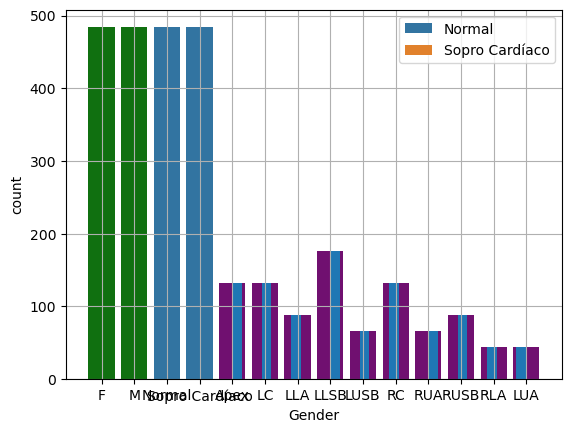

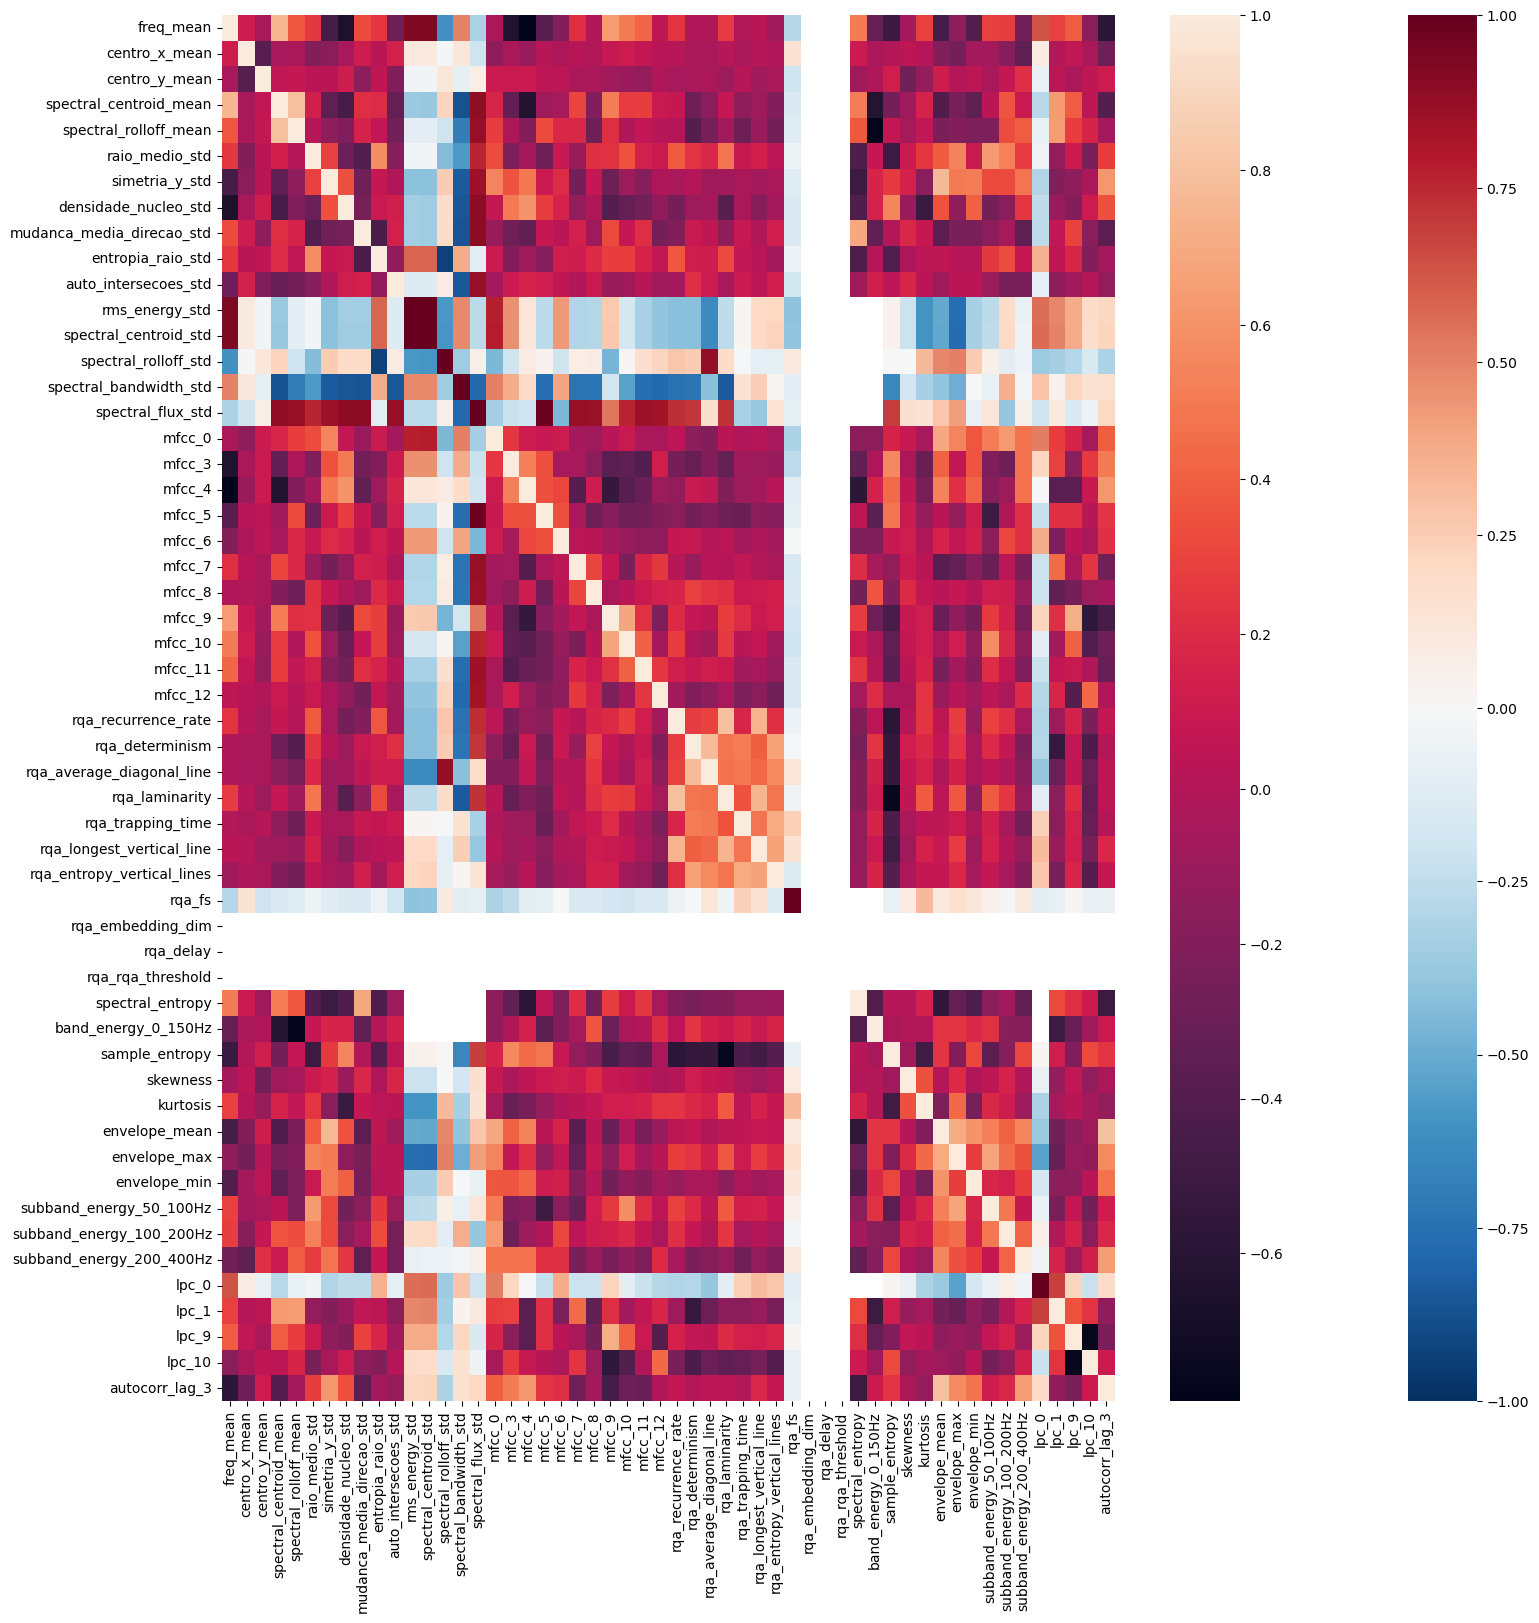

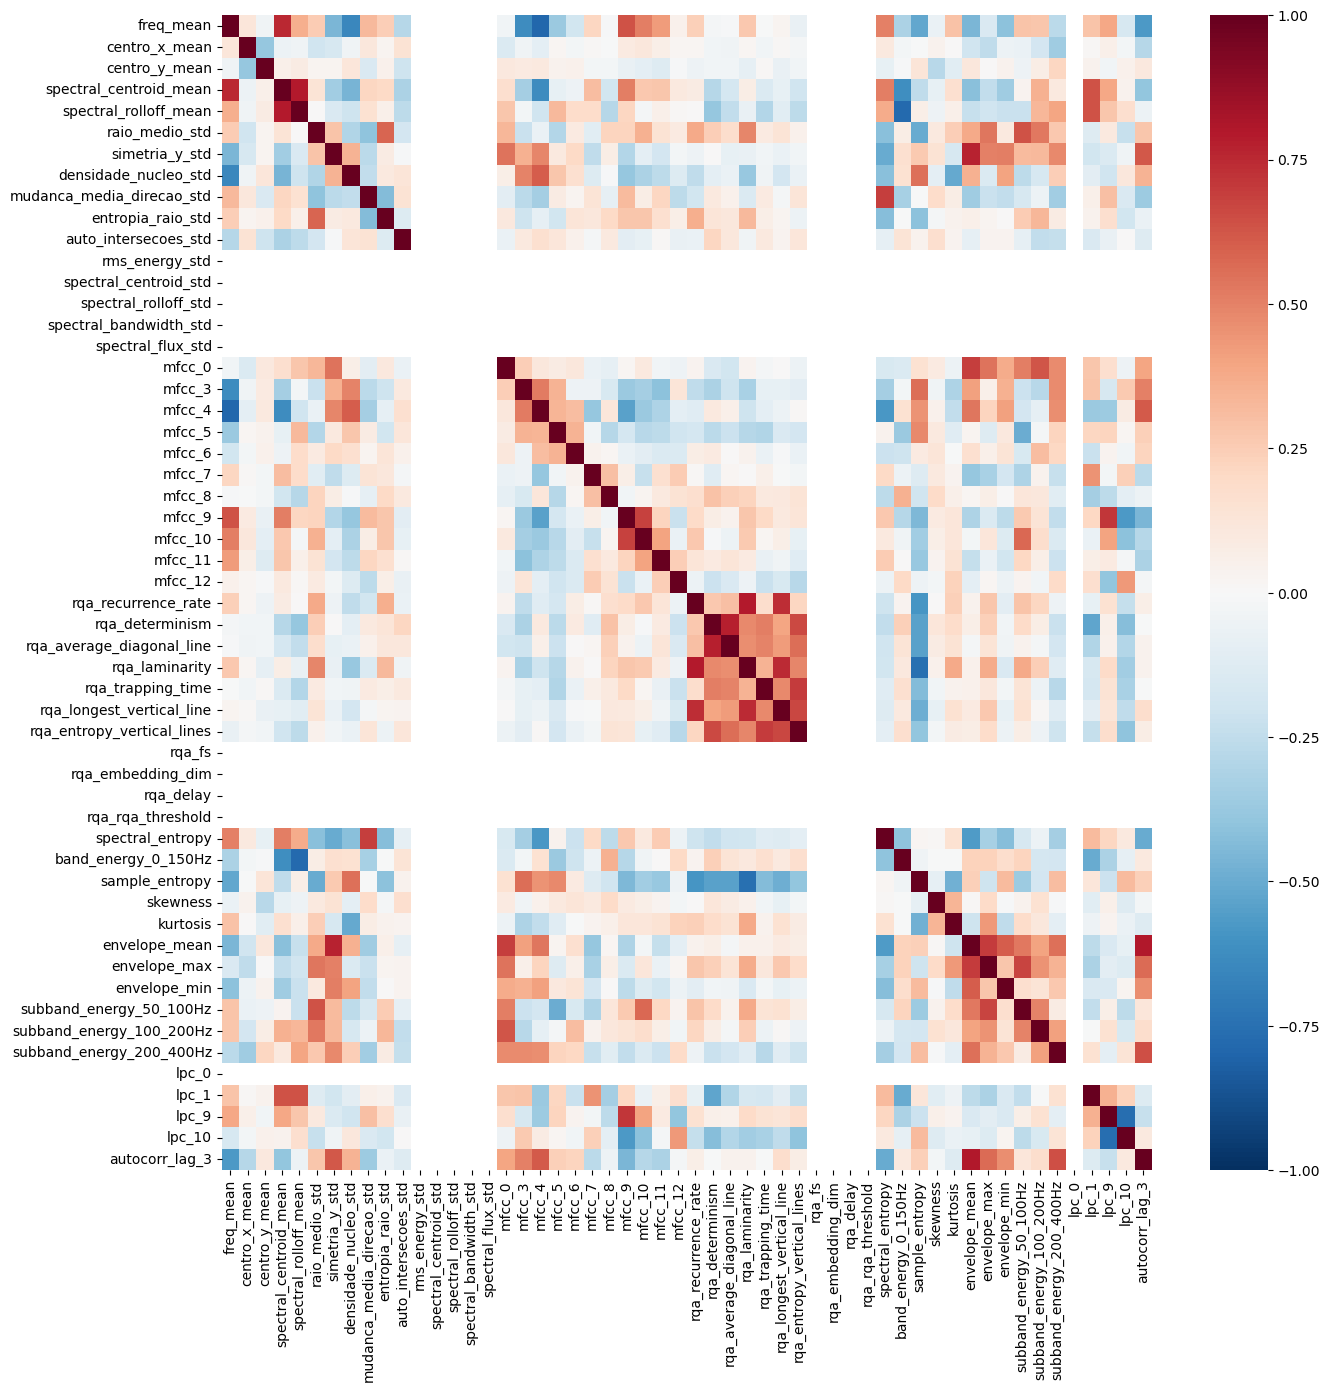

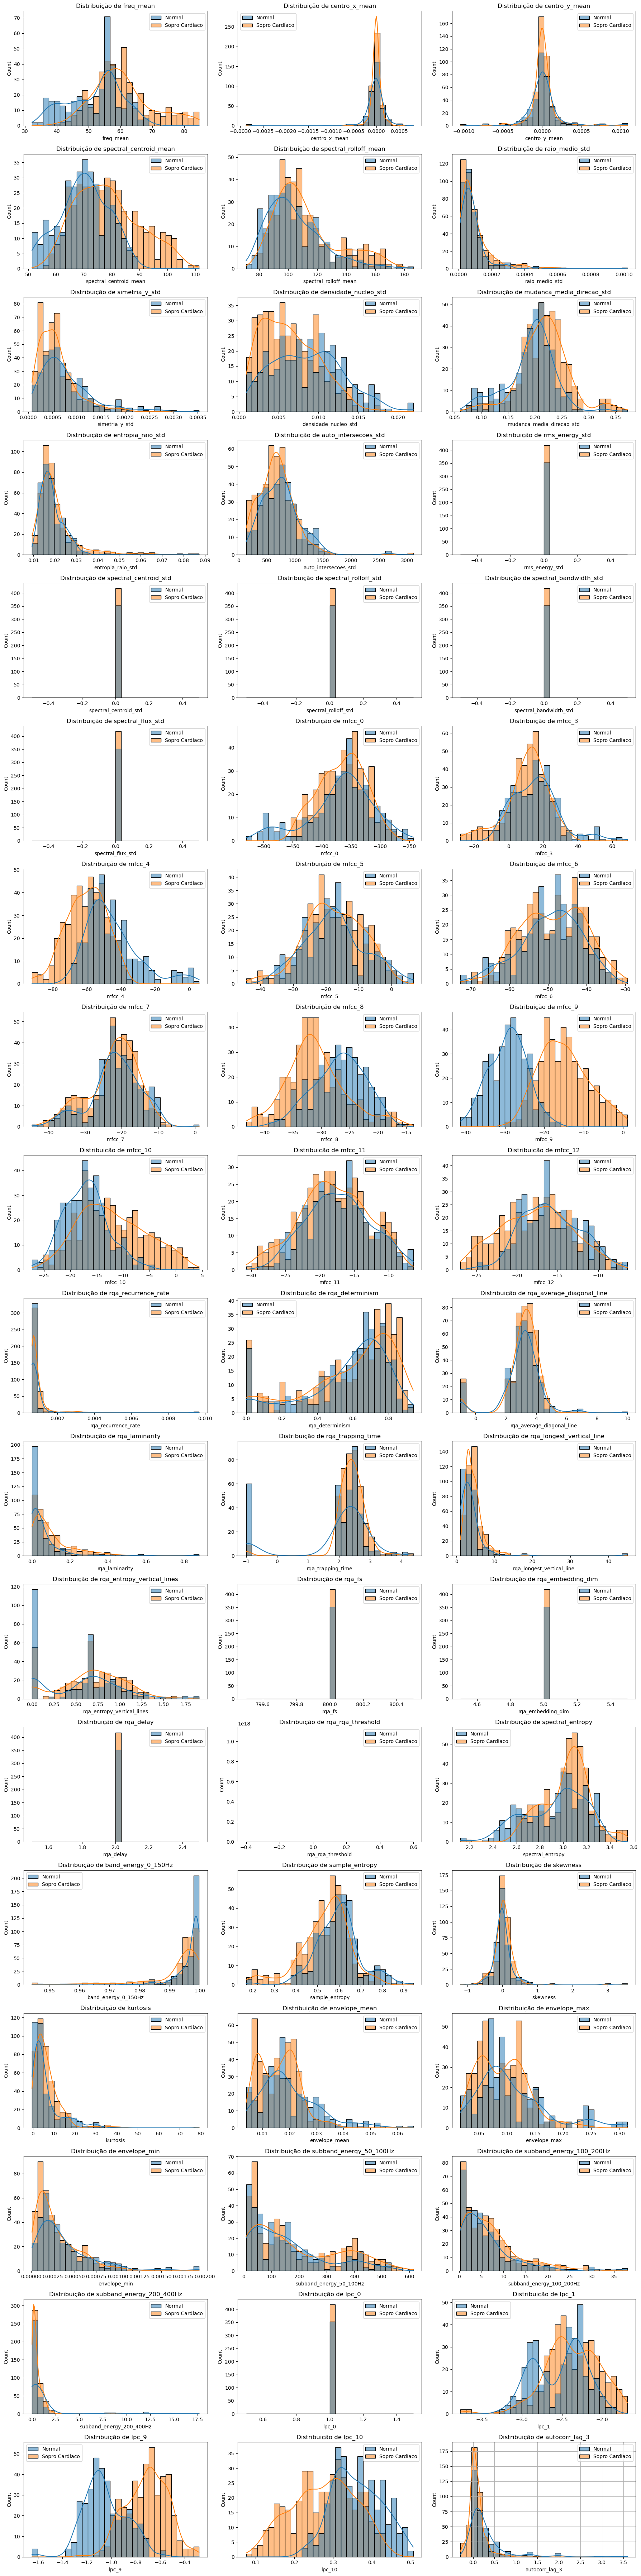

In [332]:

import math  

plot_df = X_train_reduced.join(y_train)
target_column_name = y_train.name

numeric_cols = X_train_reduced.select_dtypes(include=np.number).columns
n_features = len(numeric_cols)

ncols = 3  
nrows = math.ceil(n_features / ncols) 

fig, axes = plt.subplots(nrows=nrows, ncols=ncols,
                         figsize=(ncols * 6, nrows * 4))

axes = axes.flatten()

for i, column in enumerate(numeric_cols):
    ax = axes[i]  

    try:
        sns.histplot(data=plot_df, x=column,
                     hue=target_column_name, kde=True, bins=30, ax=ax)
    except LinAlgError:
        print(f"AVISO: Não foi possível calcular o KDE para '{column}'. Gerando novamente sem KDE.")
        sns.histplot(data=plot_df, x=column,
                     hue=target_column_name, kde=False, bins=30, ax=ax)

    ax.set_title(f'Distribuição de {column}', fontsize=12)
    ax.legend_.set_title(None)  

for i in range(n_features, len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.grid(True)
plt.show()

Analisando e deletando as _features_ contínuas de valores constantes, pois não apresentam qualquer variabilidade.

In [333]:
cols_constantes = [
    col for col in X_train_reduced.columns if X_train_reduced[col].nunique() == 1]

print("Colunas com valor constante:", cols_constantes)


X_train_reduced = X_train_reduced.drop(columns=cols_constantes, errors='ignore')
# X_test_reduced = X_test_reduced.drop(
#     columns=cols_constantes, errors='ignore')

Colunas com valor constante: ['rms_energy_std', 'spectral_centroid_std', 'spectral_rolloff_std', 'spectral_bandwidth_std', 'spectral_flux_std', 'rqa_fs', 'rqa_embedding_dim', 'rqa_delay', 'rqa_rqa_threshold', 'lpc_0']


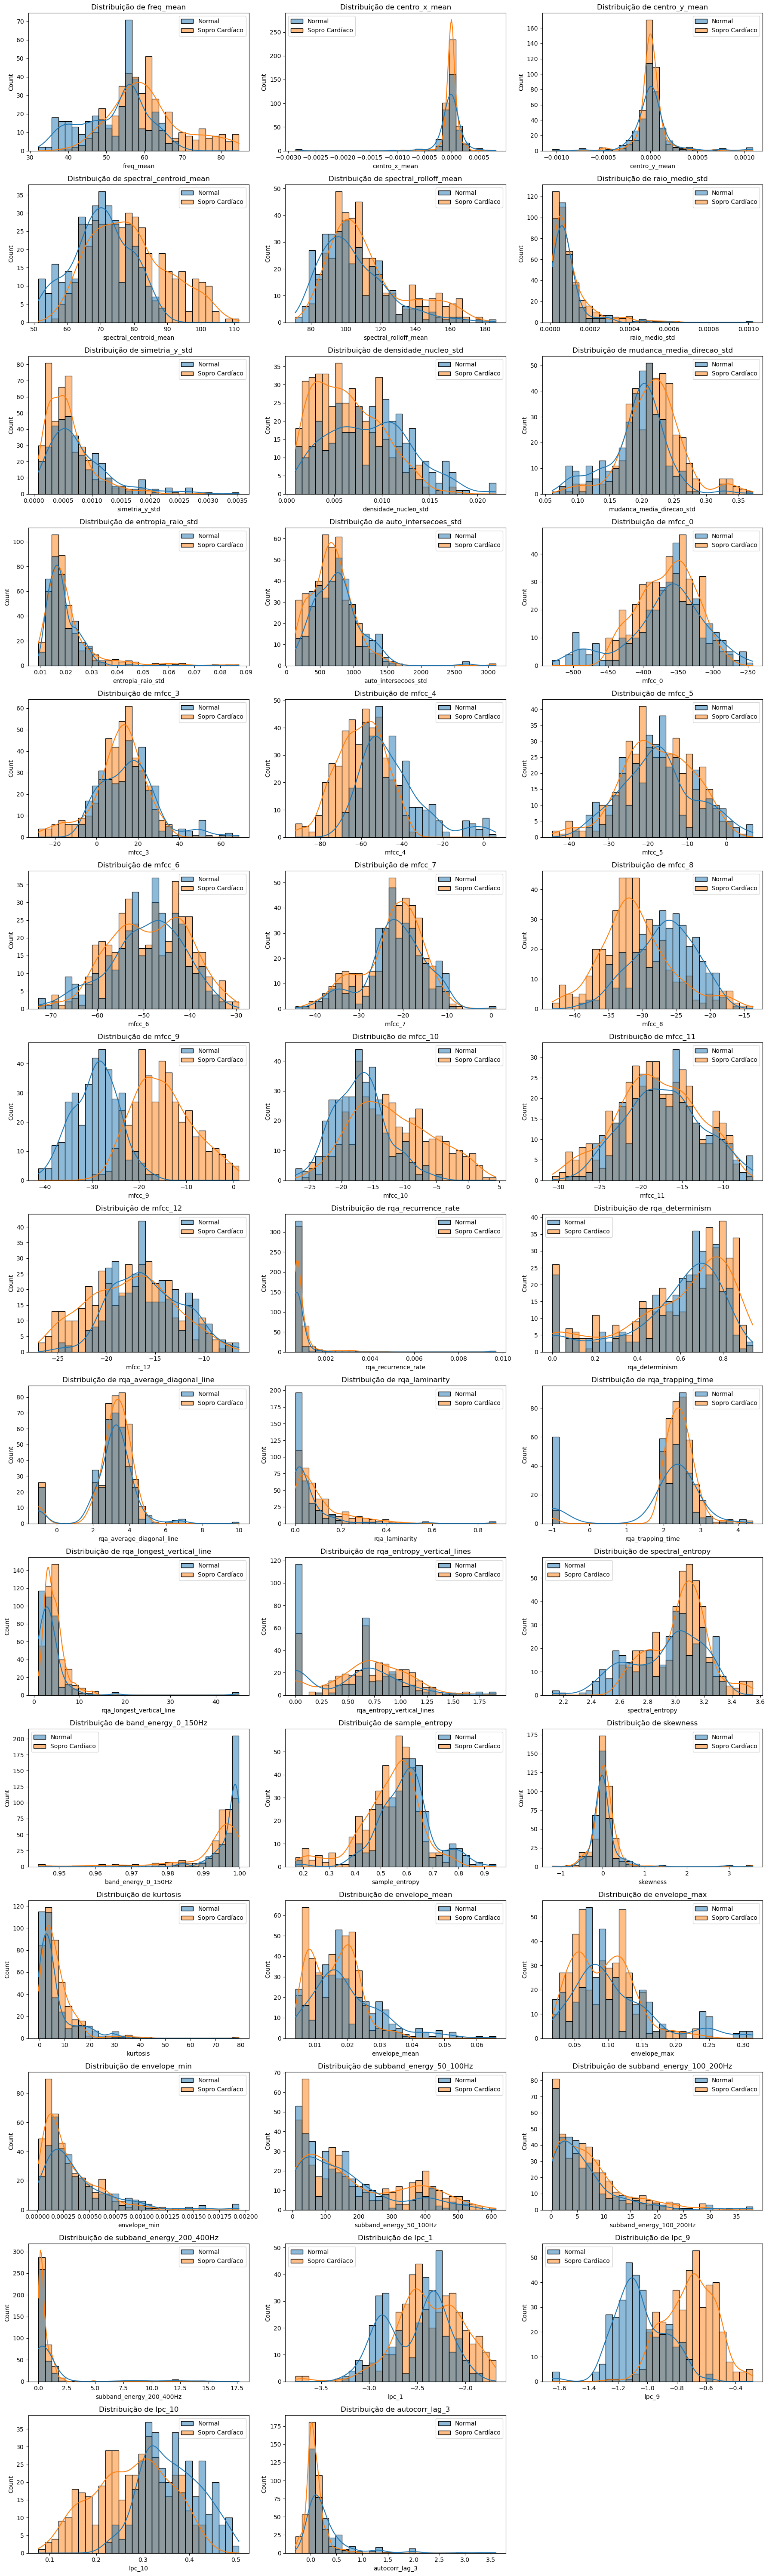

In [334]:
plot_df = X_train_reduced.join(y_train)
target_column_name = y_train.name

numeric_cols = X_train_reduced.select_dtypes(include=np.number).columns
n_features = len(numeric_cols)

ncols = 3
nrows = math.ceil(n_features / ncols)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols,
                         figsize=(ncols * 6, nrows * 4))

axes = axes.flatten()

for i, column in enumerate(numeric_cols):
    ax = axes[i]

    try:
        sns.histplot(data=plot_df, x=column,
                     hue=target_column_name, kde=True, bins=30, ax=ax)
    except LinAlgError:
        print(
            f"AVISO: Não foi possível calcular o KDE para '{column}'. Gerando novamente sem KDE.")
        sns.histplot(data=plot_df, x=column,
                     hue=target_column_name, kde=False, bins=30, ax=ax)

    ax.set_title(f'Distribuição de {column}', fontsize=12)
    ax.legend_.set_title(None)

for i in range(n_features, len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.grid(True)
plt.show()

#### 3.3 Mutual Information

Medir quanto de informação uma feature contém sobre o rótulo (target), seja linear, não-linear, monotônica ou não.

Natureza: medida não-paramétrica de dependência estatística entre duas variáveis.

Interpretação:

- MI(X, Y) = 0 ⟺ X e Y são estatisticamente independentes.
- MI(X, Y) > 0 ⟺ há alguma relação informativa entre X e Y, linear ou não.

Estimamos o grau de dependência.

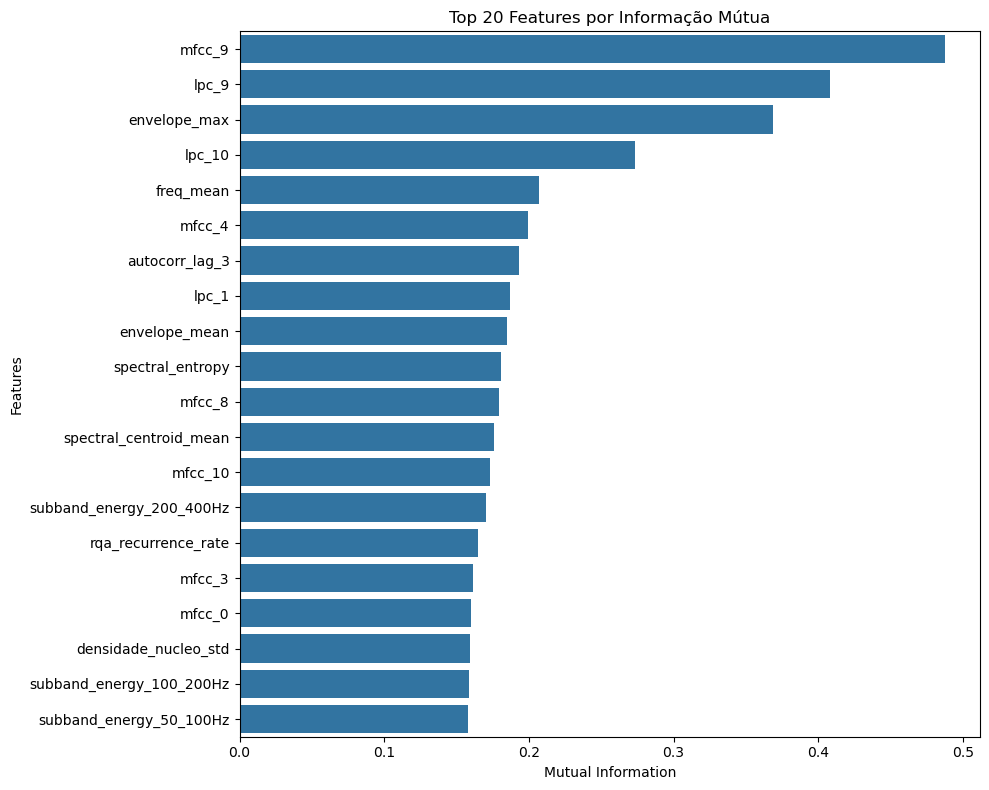

In [335]:

mi_scores = mutual_info_classif(X_train_reduced, y_train, random_state=42)
mi_series = pd.Series(mi_scores, index=X_train_reduced.columns, name="MI Score")
mi_series = mi_series.sort_values(ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x=mi_series.head(20), y=mi_series.head(20).index)
plt.title("Top 20 Features por Informação Mútua")
plt.xlabel("Mutual Information")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

### 3.4 Análise de Dimensionalidade

O objetivo é reduzir o número de dimensões para 2D ou 3D, preservando a estrutura de variabilidade dos dados, para:

- Visualizar separabilidade entre classes;
- Identificar clusters ou sobreposições;
- Detectar ruído ou _outliers_.

**Métodos**:

- **PCA (Principal Component Analysis)**
     - Linear: projeta os dados nos eixos que explicam mais variância.
     - Bom para compressão, interpretação e explicação.

- t-SNE (t-distributed Stochastic Neighbor Embedding)
     - Não linear, baseado em proximidade local entre pontos.
     - Excelente para visualização em 2D, mas não para modelagem nem generalização.



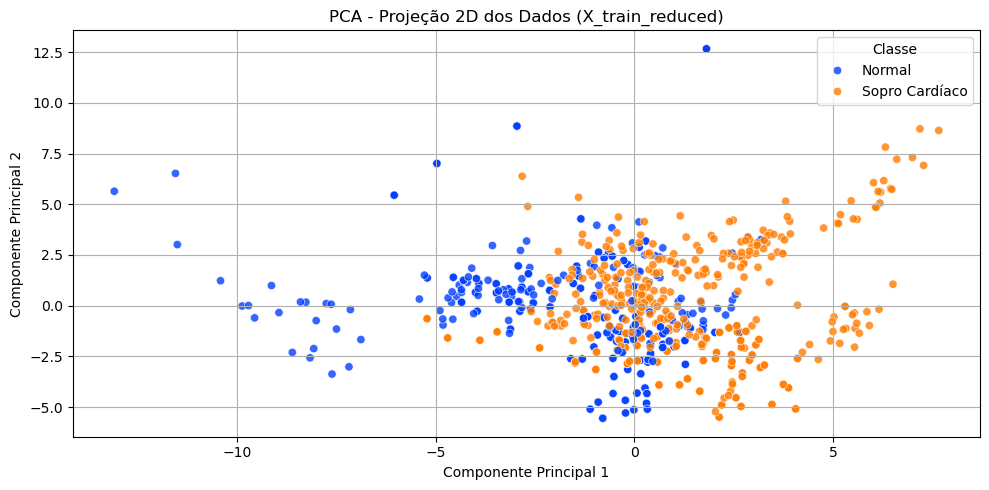

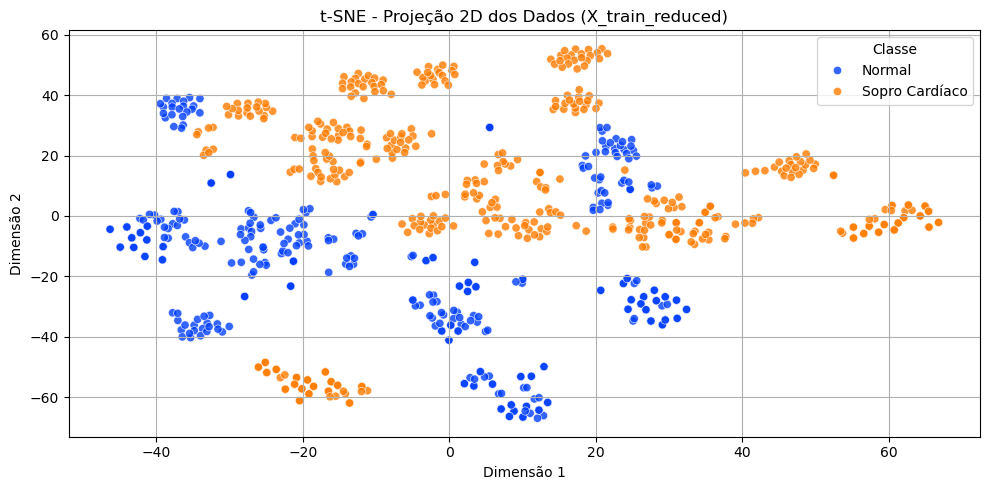

In [336]:
scaler = StandardScaler()  # Normalizando primeiro
X_scaled = scaler.fit_transform(X_train_reduced)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

tsne = TSNE(n_components=2, random_state=42, perplexity=30, learning_rate=200)
X_tsne = tsne.fit_transform(X_scaled)

df_pca = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
df_pca["Classe"] = y_train.values

df_tsne = pd.DataFrame(X_tsne, columns=["Dim1", "Dim2"])
df_tsne["Classe"] = y_train.values

plt.figure(figsize=(10, 5))
sns.scatterplot(data=df_pca, x="PC1", y="PC2",
                hue="Classe", palette="bright", alpha=0.8)
plt.title("PCA - Projeção 2D dos Dados (X_train_reduced)")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.scatterplot(data=df_tsne, x="Dim1", y="Dim2",
               hue="Classe", palette="bright", alpha=0.8)
plt.title("t-SNE - Projeção 2D dos Dados (X_train_reduced)")
plt.xlabel("Dimensão 1")
plt.ylabel("Dimensão 2")
plt.grid(True)
plt.tight_layout()
plt.show()

O PCA está mostrando alguma estrutura, mas as duas primeiras componentes não são suficientes para separação clara. Isso pode indicar que a separação entre classes está em componentes menos dominantes (dimensões escondidas).

Com t-SNE, vemos _Clusters_ bem definidos localmente, com grupos puros de classe 1. A classe 0 forma pequenos núcleos bem separados. Então, o t-SNE favorece separação local, o que sugere que há padões fortes no espaço original, mesmo que não lineares. É uma boa indicação de que o modelo pode aprender bem com algoritmos baseados em proximidade, como _Random Forest_ ou MLP. E também é um bom sinal de que os atributos capturam relações não-lineares relevantes.

|                | **PCA**              | **t-SNE**                        |
| -------------- | ------------------------------- | ----------------------------------------- |
| Baseado em  | Variância global (retas, eixos) | Proximidade local (distância de vizinhos) |
| Objetivo    | Explicar o máximo com menos     | Mostrar grupos, clusters                  |
| Linear?     | Sim                             | Não                                       |
| Interpreta? | Sim (coeficientes, vetores)     | Não (é só visual)                         |


c:\Users\pflss\miniconda3\envs\sensory-translation\lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


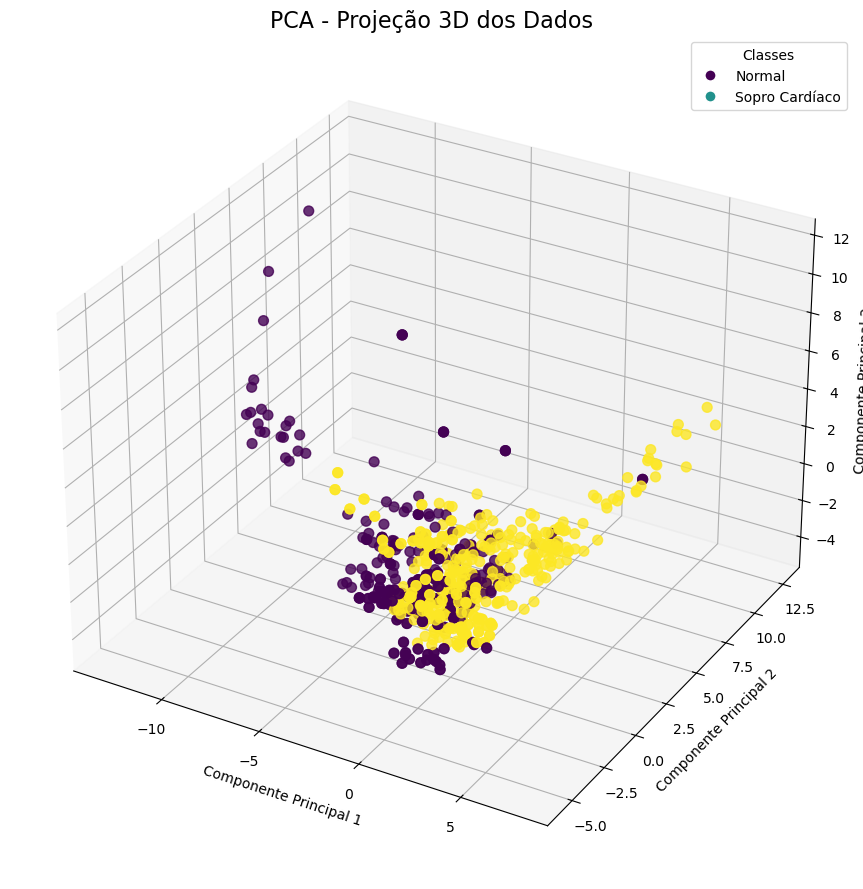

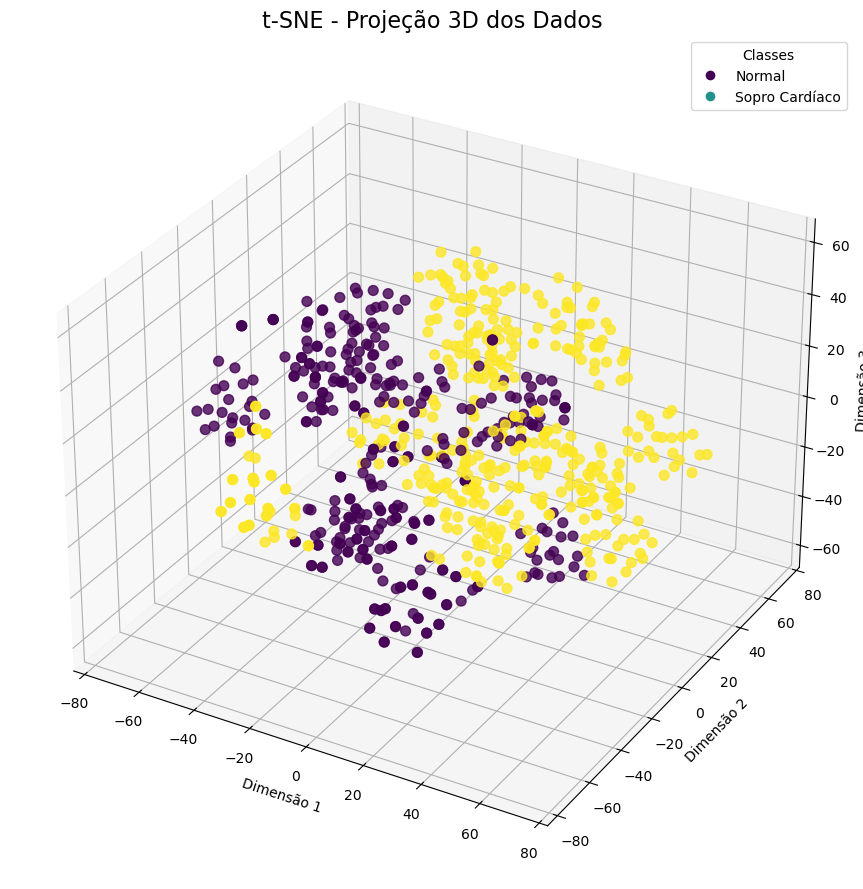

In [337]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler, LabelEncoder


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train_reduced.select_dtypes(include=np.number))


le = LabelEncoder()
y_encoded = le.fit_transform(y_train)


pca_3d = PCA(n_components=3, random_state=42)
X_pca_3d = pca_3d.fit_transform(X_scaled)

tsne_3d = TSNE(n_components=3, random_state=42,
               perplexity=30, learning_rate=200, n_iter=1000)
X_tsne_3d = tsne_3d.fit_transform(X_scaled)


fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(X_pca_3d[:, 0], X_pca_3d[:, 1], X_pca_3d[:, 2],
                     c=y_encoded, cmap='viridis', alpha=0.8, s=50)  

ax.set_title("PCA - Projeção 3D dos Dados", fontsize=16)
ax.set_xlabel("Componente Principal 1")
ax.set_ylabel("Componente Principal 2")
ax.set_zlabel("Componente Principal 3")

handles = [plt.Line2D([0], [0], marker='o', color='w',
                      markerfacecolor=plt.cm.viridis(
                          i/len(le.classes_)),  # Pega a cor do cmap
                      markersize=8) for i in range(len(le.classes_))]
ax.legend(handles, le.classes_, title="Classes")

plt.tight_layout()
plt.show()


fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(X_tsne_3d[:, 0], X_tsne_3d[:, 1], X_tsne_3d[:, 2],
                     c=y_encoded, cmap='viridis', alpha=0.8, s=50)

ax.set_title("t-SNE - Projeção 3D dos Dados", fontsize=16)
ax.set_xlabel("Dimensão 1")
ax.set_ylabel("Dimensão 2")
ax.set_zlabel("Dimensão 3")

ax.legend(handles, le.classes_, title="Classes")

plt.tight_layout()
plt.show()

# **Pré-processamento e classificação (_Data Mining_)**

In [338]:
cols_to_remove1 = to_drop.copy()
cols_to_remove2 = cols_constantes.copy()
cols_to_remove1.extend(cols_to_remove2)

## 1. Pré-processamento

In [339]:
target_col = 'Heart Sound Type'

X_train = X_train.drop(columns=to_drop + cols_constantes, errors='ignore')
X_test = X_test.drop(columns=to_drop + cols_constantes, errors='ignore')

"""Pipeline de Pré-processamento prévio e simples"""

numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_train.select_dtypes(
    include=['object', 'category']).columns.tolist()

if 'Heart Sound ID' in numeric_features:
    numeric_features.remove('Heart Sound ID')
if 'Heart Sound ID' in categorical_features:
    categorical_features.remove('Heart Sound ID')


"""
Transformador de colunas
"""
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough' 
)



## 2. Criando o Pipeline

In [340]:
""" 
criando o pipeline com o pré-processador e o classificador RandomForest
"""
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42, n_estimators=100))
])

## 3. Treinando o modelo

Iniciando o treinamento do modelo binário Normal x Sopro...

--- Resultados no Conjunto de Teste (Normal x Sopro) ---
                precision    recall  f1-score   support

        Normal       0.99      0.98      0.99       132
Sopro Cardíaco       0.97      0.98      0.98        66

      accuracy                           0.98       198
     macro avg       0.98      0.98      0.98       198
  weighted avg       0.98      0.98      0.98       198


Gerando a Matriz de Confusão...


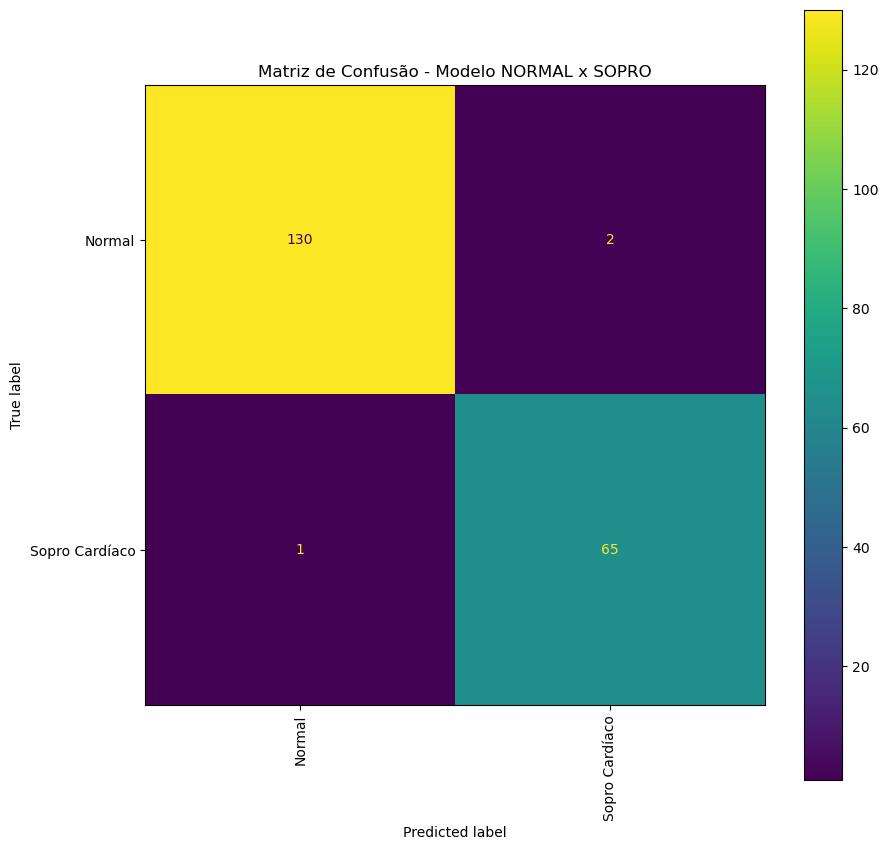

In [341]:


print("Iniciando o treinamento do modelo binário Normal x Sopro...")
model.fit(X_train, y_train)

""" avaliando o modelo"""
print("\n--- Resultados no Conjunto de Teste (Normal x Sopro) ---")
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

print("\nGerando a Matriz de Confusão...")
fig, ax = plt.subplots(figsize=(10, 10))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, ax=ax, xticks_rotation='vertical')
plt.title("Matriz de Confusão - Modelo NORMAL x SOPRO")
plt.show()

# **Verificações**

### 1. Há leakage (vazamento de dados)?
Podemos afirmar que **não há leakage**, pois usamos `GroupShuffleSplit` com `groups = X['Heart Sound ID']`.

Depois dividimos com 
`train_idx, test_idx = next(gss.split(X, y, groups=groups))`

E verificamos explicitamente a interseção:

```python
train_audios = set(X_train['Heart Sound ID'].unique())
test_audios = set(X_test['Heart Sound ID'].unique())
print("Audios vazados (interseção):", train_audios.intersection(test_audios))
```

Resultado da célula: `set()` —> sem IDs vazando entre treino e teste. Perfeito.

### 2. Está havendo normalização?
Sim. O trecho abaixo confirma:


```python
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough'
)
```

O `StandardScaler()` está normalizando todas as colunas numéricas.

### 3. O pré-processamento está dentro do Pipeline?
Sim, pois fazemos:

```python
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(...))
])
```

Isso garante que o fit e o predict sempre passam pelo mesmo pré-processamento, sem risco de inconsistência ou vazamento acidental.

## Verificando a curva de aprendizado e as métricas nos dados de treino para confirmar que não há _overfitting_:

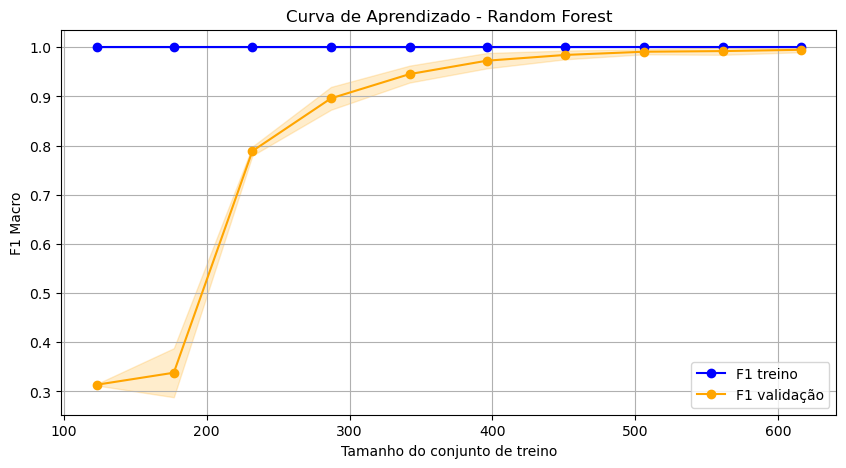

In [342]:
from sklearn.model_selection import learning_curve, StratifiedKFold

train_sizes, train_scores, val_scores = learning_curve(
    estimator=model,
    X=X_train,
    y=y_train,
    train_sizes=np.linspace(0.2, 1.0, 10),
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1_macro',
    n_jobs=-1
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

plt.figure(figsize=(10, 5))
plt.plot(train_sizes, train_mean, 'o-', color='blue', label='F1 treino')
plt.fill_between(train_sizes, train_mean - train_std,
                 train_mean + train_std, alpha=0.2, color='blue')
plt.plot(train_sizes, val_mean, 'o-', color='orange', label='F1 validação')
plt.fill_between(train_sizes, val_mean - val_std, val_mean +
                 val_std, alpha=0.2, color='orange')
plt.title("Curva de Aprendizado - Random Forest")
plt.xlabel("Tamanho do conjunto de treino")
plt.ylabel("F1 Macro")
plt.legend()
plt.grid()
plt.show()

A curva que geramos está boa para diagnóstico, e ela revela uma situação clássica de _overfitting_ em conjunto pequeno, mas que é resolvida conforme o tamanho dos dados cresce:

🔹 Região à esquerda (poucos dados de treino)
- F1 treino = 1.0
- F1 validação = muito baixo (0.3–0.4)
- Diferença enorme ==> Overfitting claro com poucos dados

Isso é esperado! Com poucas amostras, o modelo "decorou" o treino.

🔸 Região intermediária (250–400)
- A F1 de validação sobe rapidamente
- A diferença entre treino e validação diminui

Isso indica que o modelo começa a generalizar melhor, perdendo a rigidez do overfitting.

🔹 Região à direita (500+ amostras)
- F1 treino ≈ 1.0
- F1 validação ≈ 1.0
- As curvas se encontram.

Isso é o ideal! Overfitting não está mais ocorrendo.

O modelo estava _overfitting_ com poucos dados, o que é esperado. Com mais dados, ele aprende a generalizar.

A curva prova que o modelo é robusto e o pipeline parece confiável.



## Utilizando `StratifiedGroupKFold`

### Quando um modelo apresenta 100% de acurácia, F1-score perfeito e zero erros na matriz de confusão, é necessário considerar com cautela o que isso realmente significa. Existem três explicações possíveis:

---

### 1. Vazamento de Dados (Data Leakage)

Esse é o motivo mais comum quando se observa desempenho perfeito. O vazamento ocorre quando o modelo tem acesso, direta ou indiretamente, a informações que ele não deveria ver durante o treinamento, como:

- Colunas altamente correlacionadas com o rótulo (target)
- Identificadores como ID, localização anatômica, ou gênero
- Pré-processamento incorreto antes da divisão entre treino e teste

Mesmo com a separação dos dados, se houver qualquer variável que “entregue” o rótulo, o modelo irá memorizar a resposta.

**No projeto atual**, o risco de vazamento foi mitigado ao:

- Usar `GroupShuffleSplit` e `StratifiedGroupKFold` para garantir que os mesmos áudios (`Heart Sound ID`) não estivessem presentes em treino e teste
- Remover colunas irrelevantes ou perigosas como `Gender`, `Location`, `Heart Sound ID` antes do treinamento

---

### 2. Overfitting (Sobreajuste)

Mesmo sem vazamento explícito, o modelo pode simplesmente estar memorizando os dados de treino, sem aprender a generalizar. Isso é caracterizado por:

- Desempenho perfeito no treino
- Queda de desempenho em validação
- Curvas de aprendizado com grande distância entre treino e validação

**No projeto atual**, o overfitting foi avaliado e controlado por meio de:

- Validação cruzada com `StratifiedGroupKFold`
- Uso de `learning_curve()` para observar se o desempenho melhora ou se estabiliza
- Inclusão de pipeline completo com pré-processamento embutido, evitando contaminação

---

### 3. Tarefa excessivamente simples

Em raros casos, um problema pode ser realmente fácil a ponto de permitir acurácia perfeita. Isso geralmente ocorre com datasets extremamente limpos, separáveis e sem ruído. No entanto, em aplicações reais, especialmente biomédicas, esse cenário é raro e deve ser sempre colocado em dúvida.

---

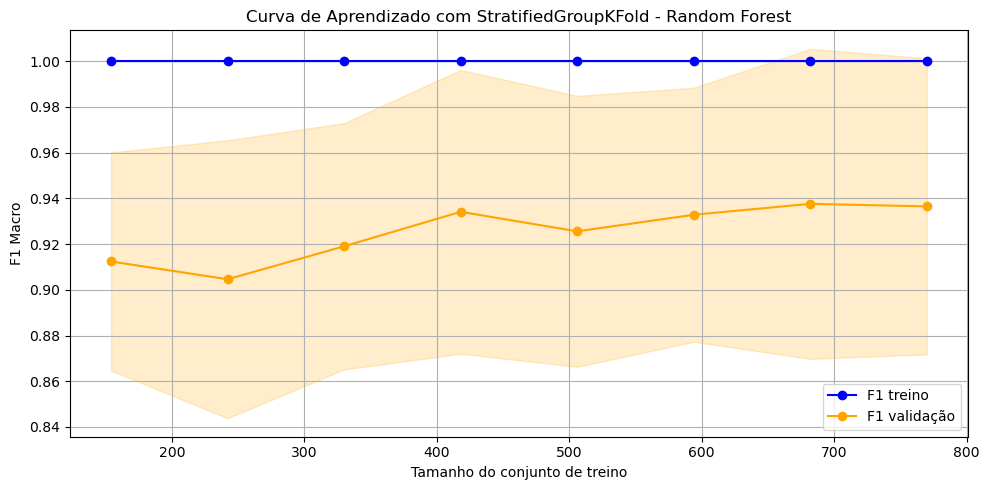


Relatório de Classificação (Validação Cruzada com Grupos):
                precision    recall  f1-score   support

        Normal       0.93      0.93      0.93       484
Sopro Cardíaco       0.93      0.93      0.93       484

      accuracy                           0.93       968
     macro avg       0.93      0.93      0.93       968
  weighted avg       0.93      0.93      0.93       968



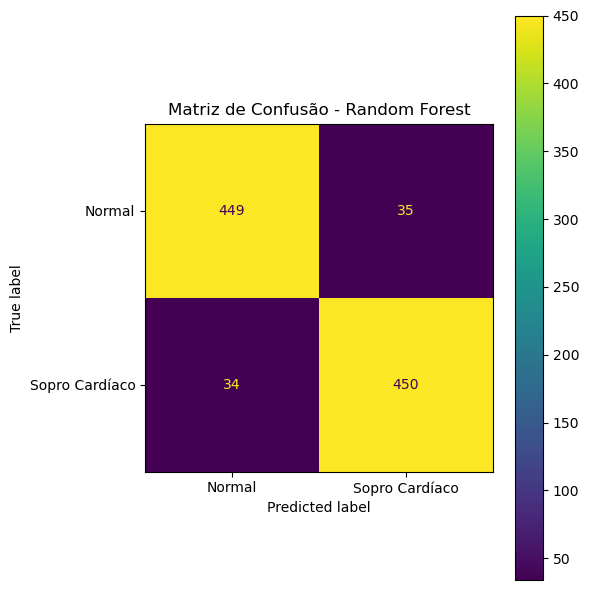

In [343]:
from sklearn.model_selection import StratifiedGroupKFold, learning_curve, cross_val_predict
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# ============================
# 1. Preparação dos Dados
# ============================
X_bin = X.copy()
y_bin = y.copy()

groups = X_bin['Heart Sound ID']  
cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

num_cols = X_bin.select_dtypes(include=np.number).columns.tolist()
cat_cols = X_bin.select_dtypes(include='object').columns.tolist()

if 'Heart Sound ID' in num_cols:
    num_cols.remove('Heart Sound ID')
if 'Heart Sound ID' in cat_cols:
    cat_cols.remove('Heart Sound ID')

# ============================
# 2. Pipeline (Pré-processamento + Modelo)
# ============================
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

# ============================
# 3. Curva de Aprendizado
# ============================
train_sizes, train_scores, val_scores = learning_curve(
    estimator=pipeline,
    X=X_bin.drop(columns='Heart Sound ID'),
    y=y_bin,
    groups=groups,
    cv=cv,
    train_sizes=np.linspace(0.2, 1.0, 8),
    scoring='f1_macro',
    n_jobs=-1,
    shuffle=True,
    random_state=42
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

plt.figure(figsize=(10, 5))
plt.plot(train_sizes, train_mean, 'o-', color='blue', label='F1 treino')
plt.fill_between(train_sizes, train_mean - train_std,
                 train_mean + train_std, alpha=0.2, color='blue')
plt.plot(train_sizes, val_mean, 'o-', color='orange', label='F1 validação')
plt.fill_between(train_sizes, val_mean - val_std, val_mean +
                 val_std, alpha=0.2, color='orange')
plt.title('Curva de Aprendizado com StratifiedGroupKFold - Random Forest')
plt.xlabel('Tamanho do conjunto de treino')
plt.ylabel('F1 Macro')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ============================
# 4. Predição com Validação Cruzada
# ============================

y_pred = cross_val_predict(
    estimator=pipeline,
    X=X_bin.drop(columns='Heart Sound ID'),
    y=y_bin,
    groups=groups,
    cv=cv,
    n_jobs=-1
)

# ============================
# 5. Métricas e Matriz de Confusão
# ============================
print("\nRelatório de Classificação (Validação Cruzada com Grupos):")
print(classification_report(y_bin, y_pred))

fig, ax = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay.from_predictions(y_bin, y_pred, ax=ax)
plt.title('Matriz de Confusão - Random Forest')
plt.tight_layout()
plt.show()

# **Testando outros modelos**

In [344]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedGroupKFold, cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import matplotlib.pyplot as plt
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.svm import SVC


X_copy = X.copy()
X_copy = X_copy.drop(columns=to_drop + cols_constantes, errors='ignore')
y_copy = y.copy()

X_features = X_copy.drop(columns='Heart Sound ID')
groups = X_copy['Heart Sound ID']
y_true = y_copy

num_cols = X_features.select_dtypes(include='number').columns.tolist()
cat_cols = X_features.select_dtypes(include='object').columns.tolist()

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

## 1. Regressão Logística 

                precision    recall  f1-score   support

        Normal       0.98      0.99      0.99       484
Sopro Cardíaco       0.99      0.98      0.99       484

      accuracy                           0.99       968
     macro avg       0.99      0.99      0.99       968
  weighted avg       0.99      0.99      0.99       968



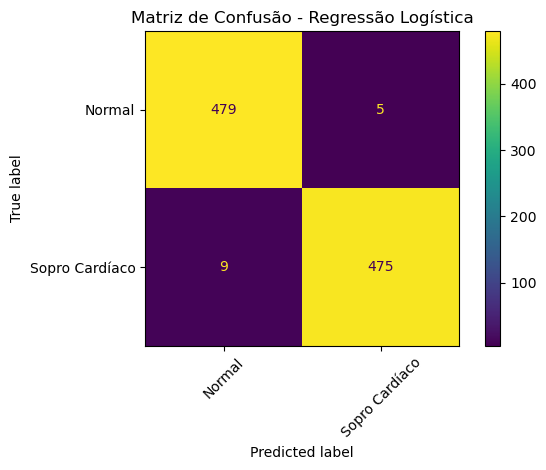


GERANDO LEARNING CURVE - REGRESSÃO LOGÍSTICA


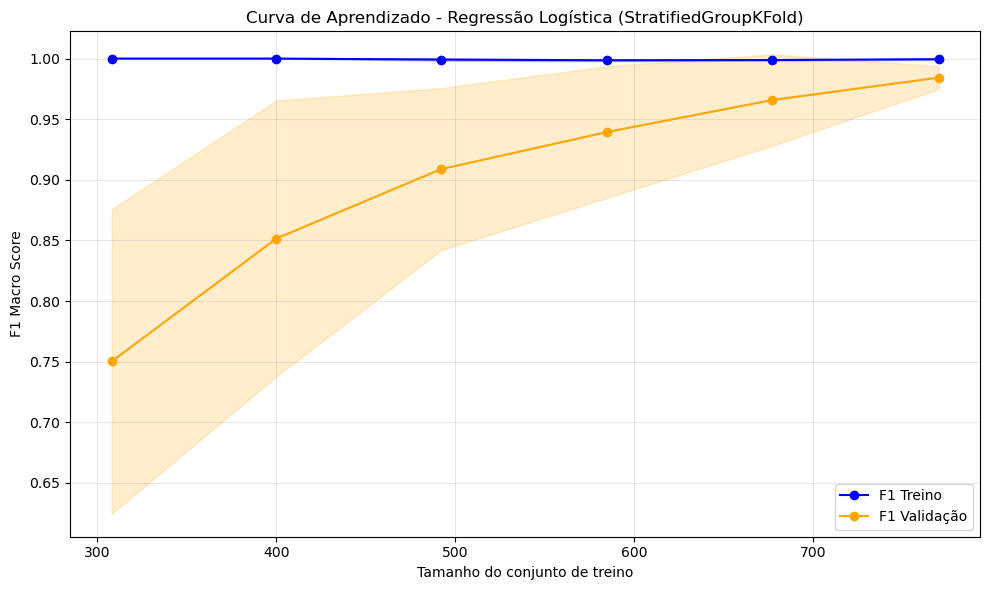


ANÁLISE DA LEARNING CURVE:
F1 Treino (final): 0.999 (±0.001)
F1 Validação (final): 0.984 (±0.010)
Gap Treino-Validação: 0.015
Excelente! Gap muito pequeno - modelo bem generalizado


In [345]:

from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import numpy as np

clf_logreg = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000,
     multi_class='multinomial', solver='lbfgs'))
])
cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

y_pred = cross_val_predict(clf_logreg, X_features,
                           y_true, cv=cv, groups=groups, n_jobs=-1)

print(classification_report(y_true, y_pred, digits=2))

cm = confusion_matrix(y_true, y_pred)
labels = np.unique(y_true)

disp = ConfusionMatrixDisplay(cm, display_labels=labels)
disp.plot(xticks_rotation=45, cmap='viridis')
plt.title("Matriz de Confusão - Regressão Logística")
plt.tight_layout()
plt.show()


print("\n" + "="*50)
print("GERANDO LEARNING CURVE - REGRESSÃO LOGÍSTICA")
print("="*50)


train_sizes, train_scores, val_scores = learning_curve(
    estimator=clf_logreg,
    X=X_features,
    y=y_true,
    groups=groups,
    cv=cv,
    train_sizes=np.linspace(0.4, 1.0, 6),  
    scoring='f1_macro',
    n_jobs=-1,
    random_state=42
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', color='blue', label='F1 Treino')
plt.fill_between(train_sizes, train_mean - train_std,
                 train_mean + train_std, alpha=0.2, color='blue')

plt.plot(train_sizes, val_mean, 'o-', color='orange', label='F1 Validação')
plt.fill_between(train_sizes, val_mean - val_std,
                 val_mean + val_std, alpha=0.2, color='orange')

plt.title('Curva de Aprendizado - Regressão Logística (StratifiedGroupKFold)')
plt.xlabel('Tamanho do conjunto de treino')
plt.ylabel('F1 Macro Score')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nANÁLISE DA LEARNING CURVE:")
print(f"F1 Treino (final): {train_mean[-1]:.3f} (±{train_std[-1]:.3f})")
print(f"F1 Validação (final): {val_mean[-1]:.3f} (±{val_std[-1]:.3f})")
print(f"Gap Treino-Validação: {train_mean[-1] - val_mean[-1]:.3f}")

if train_mean[-1] - val_mean[-1] < 0.05:
    print("Excelente! Gap muito pequeno - modelo bem generalizado")
elif train_mean[-1] - val_mean[-1] < 0.15:
    print("Bom! Gap moderado - leve overfitting")
else:
    print("Atenção! Gap grande - possível overfitting")

## 2. HistGradientBoostingClassifier

                precision    recall  f1-score   support

        Normal       0.96      0.97      0.96       484
Sopro Cardíaco       0.97      0.96      0.96       484

      accuracy                           0.96       968
     macro avg       0.96      0.96      0.96       968
  weighted avg       0.96      0.96      0.96       968



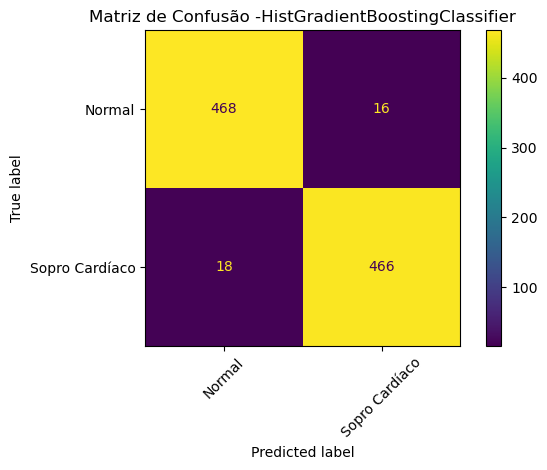


GERANDO LEARNING CURVE


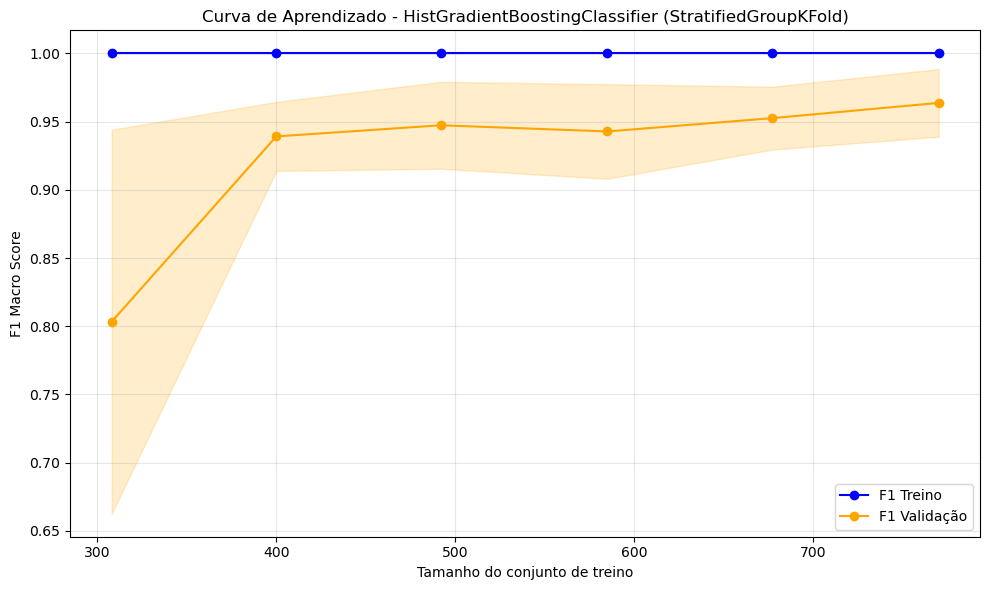


ANÁLISE DA LEARNING CURVE:
F1 Treino (final): 1.000 (±0.000)
F1 Validação (final): 0.964 (±0.025)
Gap Treino-Validação: 0.036
Excelente! Gap muito pequeno - modelo bem generalizado


In [346]:


clf_hgb = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', HistGradientBoostingClassifier(random_state=42))
])
cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

y_pred = cross_val_predict(clf_hgb, X_features,
                           y_true, cv=cv, groups=groups, n_jobs=-1)

print(classification_report(y_true, y_pred, digits=2))

cm = confusion_matrix(y_true, y_pred)
labels = np.unique(y_true)  

disp = ConfusionMatrixDisplay(
    cm, display_labels=labels
)
disp.plot(xticks_rotation=45, cmap='viridis')
plt.title("Matriz de Confusão -HistGradientBoostingClassifier")
plt.tight_layout()
plt.show()

print("\n" + "="*50)
print("GERANDO LEARNING CURVE")
print("="*50)


train_sizes, train_scores, val_scores = learning_curve(
    estimator=clf_hgb,
    X=X_features,
    y=y_true,
    groups=groups,
    cv=cv,
    train_sizes=np.linspace(0.4, 1.0, 6),  
    scoring='f1_macro',
    n_jobs=-1,
    random_state=42
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', color='blue', label='F1 Treino')
plt.fill_between(train_sizes, train_mean - train_std,
                 train_mean + train_std, alpha=0.2, color='blue')

plt.plot(train_sizes, val_mean, 'o-', color='orange', label='F1 Validação')
plt.fill_between(train_sizes, val_mean - val_std,
                 val_mean + val_std, alpha=0.2, color='orange')

plt.title('Curva de Aprendizado - HistGradientBoostingClassifier (StratifiedGroupKFold)')
plt.xlabel('Tamanho do conjunto de treino')
plt.ylabel('F1 Macro Score')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nANÁLISE DA LEARNING CURVE:")
print(f"F1 Treino (final): {train_mean[-1]:.3f} (±{train_std[-1]:.3f})")
print(f"F1 Validação (final): {val_mean[-1]:.3f} (±{val_std[-1]:.3f})")
print(f"Gap Treino-Validação: {train_mean[-1] - val_mean[-1]:.3f}")

if train_mean[-1] - val_mean[-1] < 0.05:
    print("Excelente! Gap muito pequeno - modelo bem generalizado")
elif train_mean[-1] - val_mean[-1] < 0.15:
    print("Bom! Gap moderado - leve overfitting")
else:
    print("Atenção! Gap grande - possível overfitting")

## 3. SVM

                precision    recall  f1-score   support

        Normal       0.95      0.96      0.96       484
Sopro Cardíaco       0.96      0.95      0.96       484

      accuracy                           0.96       968
     macro avg       0.96      0.96      0.96       968
  weighted avg       0.96      0.96      0.96       968



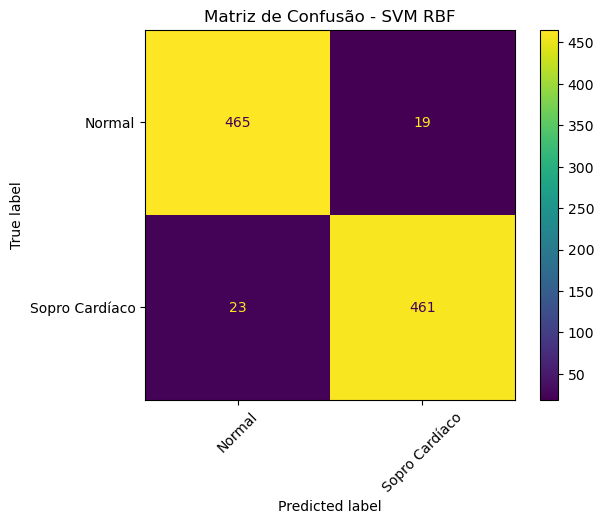


GERANDO LEARNING CURVE


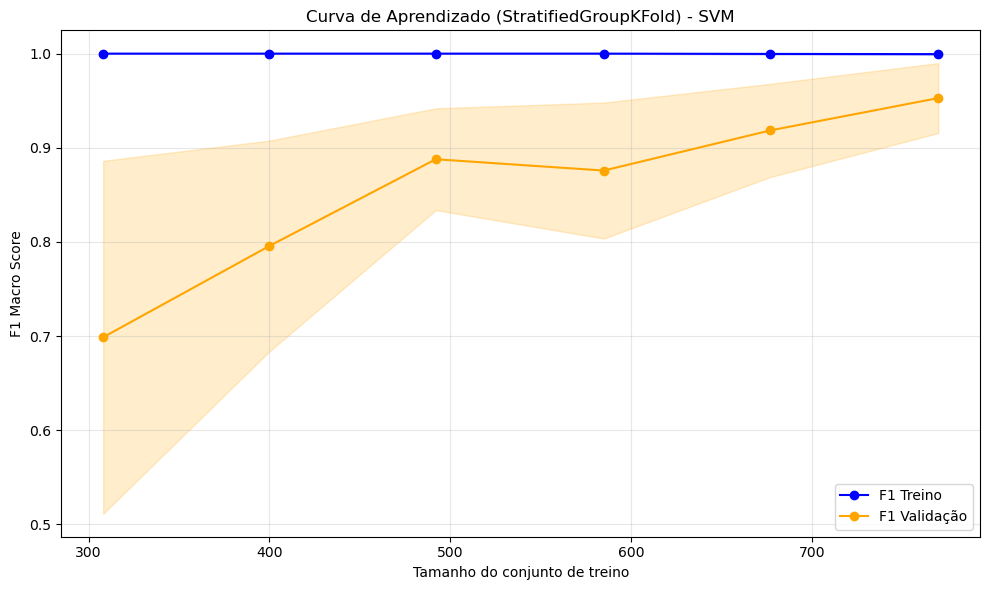


ANÁLISE DA LEARNING CURVE:
F1 Treino (final): 0.999 (±0.001)
F1 Validação (final): 0.953 (±0.037)
Gap Treino-Validação: 0.047
Excelente! Gap muito pequeno - modelo bem generalizado


In [347]:
MODEL = 'SVM'

clf_svm = Pipeline(steps=[
    ('preprocessor', preprocessor), 
    ('classifier', SVC(kernel='rbf', C=1,
     gamma='scale', probability=True, random_state=42))
])
cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)


X_features = X.drop(columns='Heart Sound ID')
groups = X['Heart Sound ID']
y_true = y

y_pred = cross_val_predict(clf_svm, X_features, y_true,
                           cv=cv, groups=groups, n_jobs=-1)

print(classification_report(y_true, y_pred, digits=2))
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=np.unique(y_true))

disp.plot(xticks_rotation=45, cmap='viridis')
plt.title("Matriz de Confusão - SVM RBF")
plt.show()

print("\n" + "="*50)
print("GERANDO LEARNING CURVE")
print("="*50)

train_sizes, train_scores, val_scores = learning_curve(
    estimator=clf_svm,
    X=X_features,
    y=y_true,
    groups=groups,
    cv=cv,
    train_sizes=np.linspace(0.4, 1.0, 6),  
    scoring='f1_macro',
    n_jobs=-1,
    random_state=42
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', color='blue', label='F1 Treino')
plt.fill_between(train_sizes, train_mean - train_std,
                 train_mean + train_std, alpha=0.2, color='blue')

plt.plot(train_sizes, val_mean, 'o-', color='orange', label='F1 Validação')
plt.fill_between(train_sizes, val_mean - val_std,
                 val_mean + val_std, alpha=0.2, color='orange')

plt.title(
    f'Curva de Aprendizado (StratifiedGroupKFold) - {MODEL}')
plt.xlabel('Tamanho do conjunto de treino')
plt.ylabel('F1 Macro Score')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nANÁLISE DA LEARNING CURVE:")
print(f"F1 Treino (final): {train_mean[-1]:.3f} (±{train_std[-1]:.3f})")
print(f"F1 Validação (final): {val_mean[-1]:.3f} (±{val_std[-1]:.3f})")
print(f"Gap Treino-Validação: {train_mean[-1] - val_mean[-1]:.3f}")

if train_mean[-1] - val_mean[-1] < 0.05:
    print("Excelente! Gap muito pequeno - modelo bem generalizado")
elif train_mean[-1] - val_mean[-1] < 0.15:
    print("Bom! Gap moderado - leve overfitting")
else:
    print("Atenção! Gap grande - possível overfitting")

## 4. KNN


🔍 KNN - Classificação com Validação Cruzada:
                precision    recall  f1-score   support

        Normal       0.91      0.93      0.92       484
Sopro Cardíaco       0.93      0.91      0.92       484

      accuracy                           0.92       968
     macro avg       0.92      0.92      0.92       968
  weighted avg       0.92      0.92      0.92       968



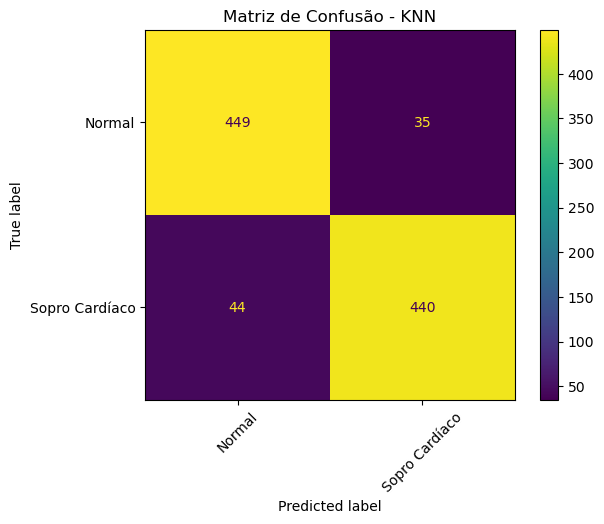


GERANDO LEARNING CURVE


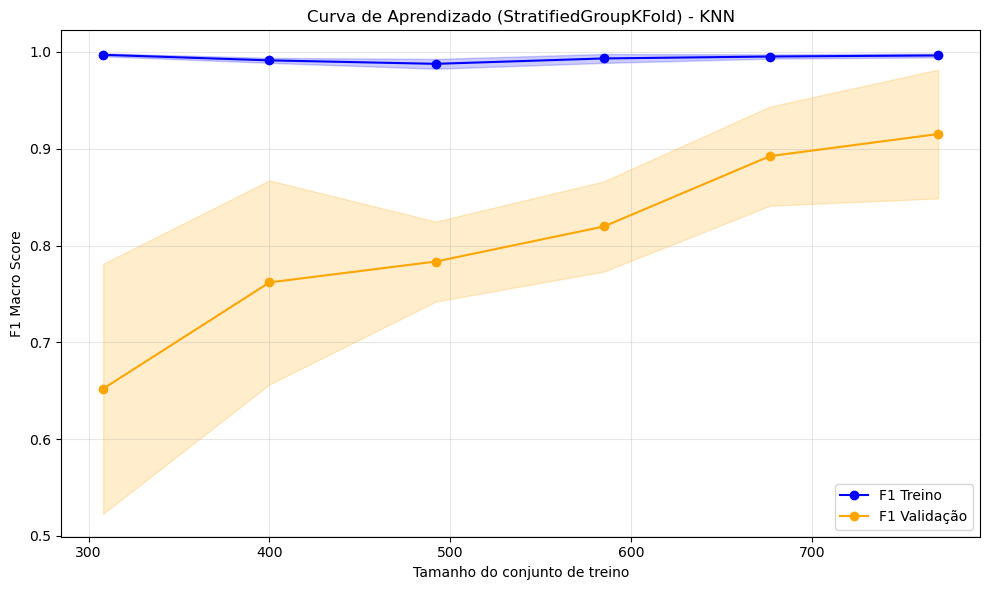


ANÁLISE DA LEARNING CURVE:
F1 Treino (final): 0.996 (±0.002)
F1 Validação (final): 0.915 (±0.067)
Gap Treino-Validação: 0.081
Bom! Gap moderado - leve overfitting


In [348]:
from sklearn.neighbors import KNeighborsClassifier

MODEL = 'KNN'
clf_knn = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', KNeighborsClassifier(n_neighbors=5))
])

X_features = X.drop(columns='Heart Sound ID')
y_true = y
groups = X['Heart Sound ID']
cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

y_pred = cross_val_predict(clf_knn, X_features, y_true,
                           cv=cv, groups=groups, n_jobs=-1)

print("\n🔍 KNN - Classificação com Validação Cruzada:")
print(classification_report(y_true, y_pred, digits=2))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=np.unique(y_true))
disp.plot(xticks_rotation=45, cmap='viridis')
plt.title("Matriz de Confusão - KNN")
plt.show()


print("\n" + "="*50)
print("GERANDO LEARNING CURVE")
print("="*50)

train_sizes, train_scores, val_scores = learning_curve(
    estimator=clf_knn,
    X=X_features,
    y=y_true,
    groups=groups,
    cv=cv,
    train_sizes=np.linspace(0.4, 1.0, 6),  
    scoring='f1_macro',
    n_jobs=-1,
    random_state=42
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', color='blue', label='F1 Treino')
plt.fill_between(train_sizes, train_mean - train_std,
                 train_mean + train_std, alpha=0.2, color='blue')

plt.plot(train_sizes, val_mean, 'o-', color='orange', label='F1 Validação')
plt.fill_between(train_sizes, val_mean - val_std,
                 val_mean + val_std, alpha=0.2, color='orange')

plt.title(
    f'Curva de Aprendizado (StratifiedGroupKFold) - {MODEL}')
plt.xlabel('Tamanho do conjunto de treino')
plt.ylabel('F1 Macro Score')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nANÁLISE DA LEARNING CURVE:")
print(f"F1 Treino (final): {train_mean[-1]:.3f} (±{train_std[-1]:.3f})")
print(f"F1 Validação (final): {val_mean[-1]:.3f} (±{val_std[-1]:.3f})")
print(f"Gap Treino-Validação: {train_mean[-1] - val_mean[-1]:.3f}")

if train_mean[-1] - val_mean[-1] < 0.05:
    print("Excelente! Gap muito pequeno - modelo bem generalizado")
elif train_mean[-1] - val_mean[-1] < 0.15:
    print("Bom! Gap moderado - leve overfitting")
else:
    print("Atenção! Gap grande - possível overfitting")

## 5. XGBoost


 XGBoost - Classificação com Validação Cruzada:
                precision    recall  f1-score   support

        Normal       0.96      0.96      0.96       484
Sopro Cardíaco       0.96      0.96      0.96       484

      accuracy                           0.96       968
     macro avg       0.96      0.96      0.96       968
  weighted avg       0.96      0.96      0.96       968



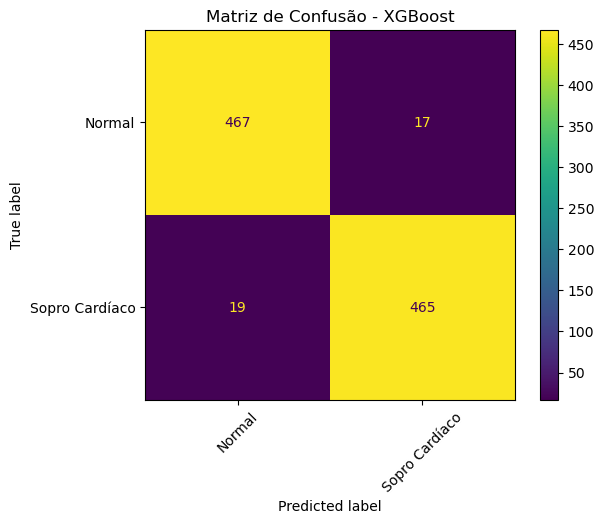


GERANDO LEARNING CURVE


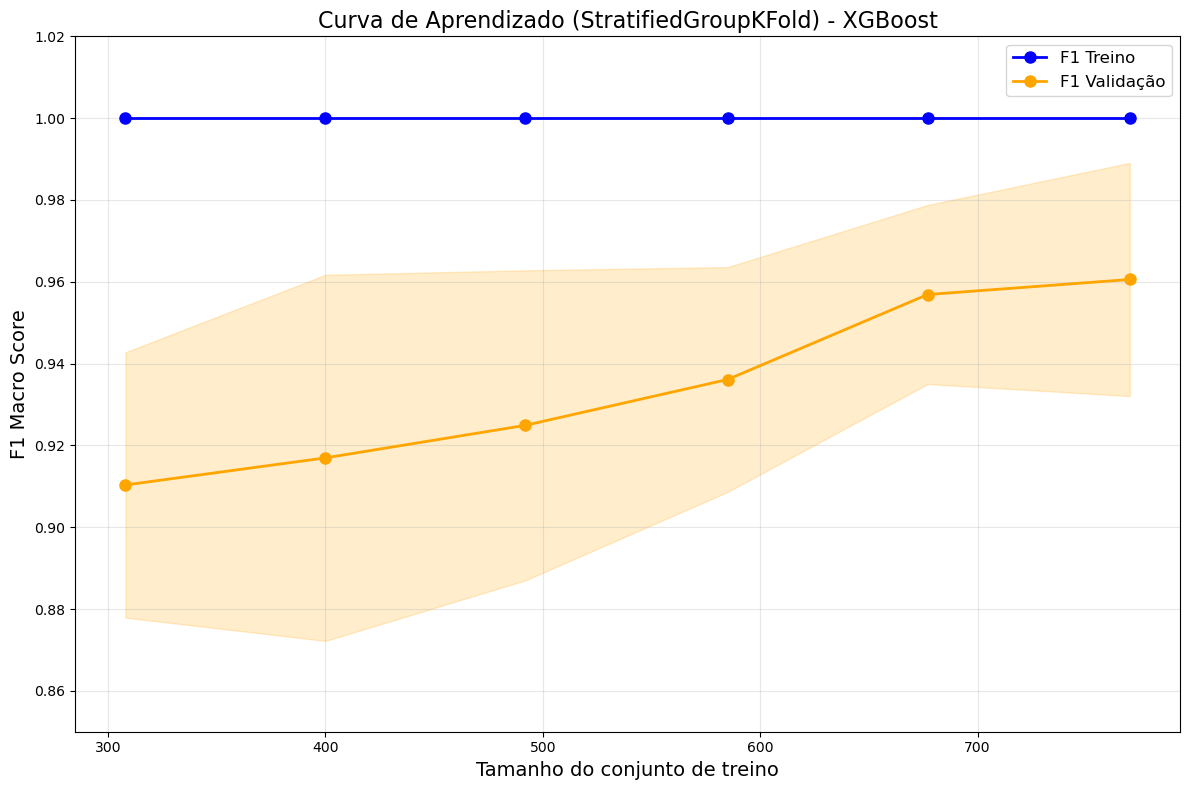


ANÁLISE DA LEARNING CURVE:
F1 Treino (final): 1.000 (±0.000)
F1 Validação (final): 0.961 (±0.028)
Gap Treino-Validação: 0.039
Excelente! Gap muito pequeno - modelo bem generalizado


In [349]:
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

MODEL = 'XGBoost'
label_encoder = LabelEncoder()
# y_true = variável com as labels originais
y_encoded = label_encoder.fit_transform(y_true)

clf_xgb = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(n_estimators=100,
     use_label_encoder=False, eval_metric='mlogloss'))
])

y_pred_encoded = cross_val_predict(
    clf_xgb, X_features, y_encoded, cv=cv, groups=groups, n_jobs=-1)

y_pred = label_encoder.inverse_transform(y_pred_encoded)

print("\n XGBoost - Classificação com Validação Cruzada:")
print(classification_report(y_true, y_pred, digits=2))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=label_encoder.classes_)
disp.plot(xticks_rotation=45, cmap='viridis')
plt.title("Matriz de Confusão - XGBoost")
plt.show()

print("\n" + "="*50)
print("GERANDO LEARNING CURVE")
print("="*50)

train_sizes, train_scores, val_scores = learning_curve(
    estimator=clf_xgb,
    X=X_features,
    y=y_encoded, 
    groups=groups,
    cv=cv,
    train_sizes=np.linspace(0.4, 1.0, 6),
    scoring='f1_macro',
    n_jobs=-1,
    random_state=42
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)


plt.figure(figsize=(12, 8)) 
plt.plot(train_sizes, train_mean, 'o-', color='blue',
         label='F1 Treino', markersize=8, linewidth=2)
plt.fill_between(train_sizes, train_mean - train_std,
                 train_mean + train_std, alpha=0.2, color='blue')

plt.plot(train_sizes, val_mean, 'o-', color='orange',
         label='F1 Validação', markersize=8, linewidth=2)
plt.fill_between(train_sizes, val_mean - val_std,
                 val_mean + val_std, alpha=0.2, color='orange')

plt.title(
    f'Curva de Aprendizado (StratifiedGroupKFold) - {MODEL}', fontsize=16)
plt.xlabel('Tamanho do conjunto de treino', fontsize=14)
plt.ylabel('F1 Macro Score', fontsize=14)

plt.ylim(0.85, 1.02)  

plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nANÁLISE DA LEARNING CURVE:")
print(f"F1 Treino (final): {train_mean[-1]:.3f} (±{train_std[-1]:.3f})")
print(f"F1 Validação (final): {val_mean[-1]:.3f} (±{val_std[-1]:.3f})")
print(f"Gap Treino-Validação: {train_mean[-1] - val_mean[-1]:.3f}")

if train_mean[-1] - val_mean[-1] < 0.05:
    print("Excelente! Gap muito pequeno - modelo bem generalizado")
elif train_mean[-1] - val_mean[-1] < 0.15:
    print("Bom! Gap moderado - leve overfitting")
else:
    print("Atenção! Gap grande - possível overfitting")

# **Classificação com Redes Neurais**

## Escolha do Modelo de Rede Neural

Como estamos lidando com dados tabulares estruturados e features extraídas (MFCC, FFT, RQA, ITS, etc.), a escolha natural é:

- MLP (Multilayer Perceptron) —> rede neural clássica, fully connected, com:
     - Entrada: vetor de características já extraídas
     - Camadas ocultas: camadas densas (com funções de ativação não-lineares)
     - Saída: softmax (multiclasse) ou sigmoid (binária)

Diferenças no Pré-Processamento (RN vs Data Mining)

| Etapa                         | Data Mining            | Redes Neurais (MLP)                                                               |
| ----------------------------- | ---------------------- | --------------------------------------------------------------------------------- |
| **Normalização/Padronização** | Nem sempre obrigatória | **Obrigatória!** Escala afeta gradientes. Usar `StandardScaler` ou `MinMaxScaler` |
| **Tratamento de Outliers**    | Moderado               | RNs são sensíveis a ruídos extremos, cuidado redobrado                            |
| **Correlação e Redundância**  | Pode manter algumas    | Deve reduzir colinearidade se exagerada (ex: PCA, seleção de features)            |
| **One-hot vs LabelEncoder**   | Varia por modelo       | Usar `LabelEncoder` (binária) ou `OneHotEncoder` (multiclasse softmax)            |


In [350]:
data.columns

Index(['Heart Sound ID', 'freq_mean', 'centro_x_mean', 'centro_y_mean',
       'raio_medio_mean', 'raio_std_mean', 'raio_max_mean', 'raio_min_mean',
       'simetria_x_mean', 'simetria_y_mean', 'densidade_nucleo_mean',
       'comprimento_curva_mean', 'variacao_curvatura_mean',
       'mudanca_media_direcao_mean', 'entropia_raio_mean',
       'auto_intersecoes_mean', 'rms_energy_mean', 'spectral_centroid_mean',
       'spectral_rolloff_mean', 'spectral_bandwidth_mean',
       'spectral_flux_mean', 'freq_std', 'centro_x_std', 'centro_y_std',
       'raio_medio_std', 'raio_std_std', 'raio_max_std', 'raio_min_std',
       'simetria_x_std', 'simetria_y_std', 'densidade_nucleo_std',
       'comprimento_curva_std', 'variacao_curvatura_std',
       'mudanca_media_direcao_std', 'entropia_raio_std',
       'auto_intersecoes_std', 'rms_energy_std', 'spectral_centroid_std',
       'spectral_rolloff_std', 'spectral_bandwidth_std', 'spectral_flux_std',
       'mfcc_0', 'mfcc_1', 'mfcc_2', 'mfcc_3',

c:\Users\pflss\miniconda3\envs\sensory-translation\lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 25s 185ms/step - accuracy: 0.6472 - loss: 0.6323 - precision: 0.6438 - recall: 0.8022 - val_accuracy: 0.9221 - val_loss: 0.3619 - val_precision: 0.9419 - val_recall: 0.9205
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.9114 - loss: 0.3121 - precision: 0.9269 - recall: 0.9123 - val_accuracy: 0.9610 - val_loss: 0.2151 - val_precision: 0.9457 - val_recall: 0.9886
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.9606 - loss: 0.1575 - precision: 0.9667 - recall: 0.9610 - val_accuracy: 0.9545 - val_loss: 0.1617 - val_precision: 0.9765 - val_recall: 0.9432
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 89ms/step - accuracy: 0.9796 - loss: 0.0905 - precision: 0.9917 - recall: 0.9702 - val_accuracy: 0.9545 - val_loss: 0.1373 - val_precision: 0.9765 - val_recall: 0.9432
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - accuracy: 0.9959 - loss: 0.0542 - precision: 0.9972 - recall: 0.9952 - val_accuracy: 0.9545 - val_loss: 0.115

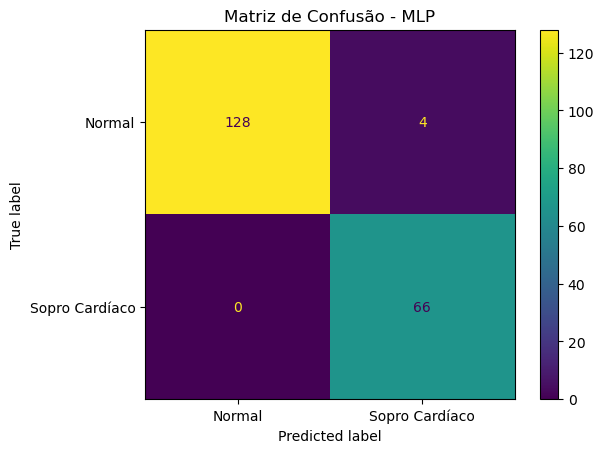

In [351]:

df = data.copy()
groups = df['Heart Sound ID']

X = df.drop(columns=['Heart Sound Type', 'Heart Sound ID'])
y = df['Heart Sound Type']

"""Codifica y (target) com LabelEncoder"""
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

"""Detecta colunas numéricas e categóricas"""
num_cols = X.select_dtypes(include=np.number).columns.tolist()
cat_cols = X.select_dtypes(include='object').columns.tolist()

"""Pré-processamento: OneHot para categóricas, StandardScaler para numéricas"""
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

"""pré-processamento completo"""
X_preprocessed = preprocessor.fit_transform(X)

"""=== SPLIT com GroupShuffleSplit ==="""
splitter = GroupShuffleSplit(test_size=0.2, random_state=42, n_splits=1)
train_idx, test_idx = next(splitter.split(
    X_preprocessed, y_encoded, groups=groups))
X_train, X_test = X_preprocessed[train_idx], X_preprocessed[test_idx]
y_train, y_test = y_encoded[train_idx], y_encoded[test_idx]

"""=== MLP ==="""
n_classes = len(np.unique(y_encoded))
final_activation = 'sigmoid' if n_classes == 2 else 'softmax'
loss_fn = 'binary_crossentropy' if n_classes == 2 else 'sparse_categorical_crossentropy'

model = Sequential([
    Dense(128, input_shape=(X_train.shape[1],), activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1 if n_classes == 2 else n_classes, activation=final_activation)
])

model.compile(
    optimizer='adam',
    loss=loss_fn,
    metrics=['accuracy', Precision(name='precision'), Recall(name='recall')]
)

"""=== TREINAMENTO ==="""
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[EarlyStopping(patience=5, restore_best_weights=True)],
    verbose=1
)

"""=== AVALIAÇÃO ==="""
y_pred_proba = model.predict(X_test)
if n_classes == 2:
    y_pred = (y_pred_proba.ravel() >= 0.5).astype(int)
else:
    y_pred = np.argmax(y_pred_proba, axis=1)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=label_encoder.classes_, cmap='viridis'
)
plt.title("Matriz de Confusão - MLP")
plt.show()

In [352]:
# df = data.copy()
# df = df.drop(columns=to_drop + cols_constantes, errors='ignore')

# X = df.drop(columns=["Heart Sound Type", "Heart Sound ID"])
# y = df["Heart Sound Type"]
# groups = df["Heart Sound ID"]

# cat_cols = X.select_dtypes(include='object').columns.tolist()
# num_cols = X.select_dtypes(include=np.number).columns.tolist()

# label_encoder = LabelEncoder()
# y_encoded = label_encoder.fit_transform(y)

# preprocessor = ColumnTransformer([
#     ('num', StandardScaler(), num_cols),
#     ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
# ])

# X_scaled = preprocessor.fit_transform(X)

# # ========================
# # Definição do modelo
# # ========================


# def build_model(input_dim):
#     model = Sequential([
#         Dense(128, input_dim=input_dim, activation='relu'),
#         Dropout(0.3),
#         Dense(64, activation='relu'),
#         Dropout(0.3),
#         Dense(1, activation='sigmoid')
#     ])
#     model.compile(
#         loss='binary_crossentropy',
#         optimizer=Adam(learning_rate=1e-3),
#         metrics=['accuracy', Precision(
#             name='precision'), Recall(name='recall')]
#     )
#     return model


# # ========================
# # Validação cruzada estratificada por grupo
# # ========================
# cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

# accuracies, precisions, recalls, f1s = [], [], [], []

# for fold, (train_idx, test_idx) in enumerate(cv.split(X_scaled, y_encoded, groups)):
#     print(f"\nFold {fold + 1}")

#     X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
#     y_train, y_test = y_encoded[train_idx], y_encoded[test_idx]

#     model = build_model(input_dim=X_scaled.shape[1])
#     history = model.fit(
#         X_train, y_train,
#         validation_split=0.2,
#         epochs=50,
#         batch_size=32,
#         callbacks=[EarlyStopping(patience=5, restore_best_weights=True)],
#         verbose=0
#     )

#     y_pred_proba = model.predict(X_test).ravel()
#     y_pred = (y_pred_proba >= 0.5).astype(int)

#     acc = np.mean(y_pred == y_test)
#     prec = precision_score(y_test, y_pred)
#     rec = recall_score(y_test, y_pred)
#     f1 = f1_score(y_test, y_pred)

#     accuracies.append(acc)
#     precisions.append(prec)
#     recalls.append(rec)
#     f1s.append(f1)

#     print(classification_report(y_test, y_pred,
#           target_names=label_encoder.classes_))


# print("\nMédia dos Resultados com StratifiedGroupKFold:")
# print(f"Acurácia média:  {np.mean(accuracies):.4f}")
# print(f"Precisão média:  {np.mean(precisions):.4f}")
# print(f"Recall médio:    {np.mean(recalls):.4f}")
# print(f"F1-Score médio:  {np.mean(f1s):.4f}")

Preparando dados para SHAP...

Iniciando cross-validation...

Fold 1


c:\Users\pflss\miniconda3\envs\sensory-translation\lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
                precision    recall  f1-score   support

        Normal       1.00      0.98      0.99       132
Sopro Cardíaco       0.96      1.00      0.98        66

      accuracy                           0.98       198
     macro avg       0.98      0.99      0.98       198
  weighted avg       0.99      0.98      0.98       198


Fold 2


c:\Users\pflss\miniconda3\envs\sensory-translation\lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
                precision    recall  f1-score   support

        Normal       1.00      1.00      1.00        66
Sopro Cardíaco       1.00      1.00      1.00       132

      accuracy                           1.00       198
     macro avg       1.00      1.00      1.00       198
  weighted avg       1.00      1.00      1.00       198


Fold 3


...

c:\Users\pflss\miniconda3\envs\sensory-translation\lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
                precision    recall  f1-score   support

        Normal       0.98      0.95      0.97       132
Sopro Cardíaco       0.90      0.97      0.93        66

      accuracy                           0.95       198
     macro avg       0.94      0.96      0.95       198
  weighted avg       0.96      0.95      0.95       198


Fold 5


c:\Users\pflss\miniconda3\envs\sensory-translation\lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
                precision    recall  f1-score   support

        Normal       0.88      0.78      0.83        88
Sopro Cardíaco       0.81      0.90      0.85        88

      accuracy                           0.84       176
     macro avg       0.85      0.84      0.84       176
  weighted avg       0.85      0.84      0.84       176


RESULTADOS FINAIS DO CROSS-VALIDATION
Acurácia média:  0.9419 ± 0.0561
Precisão média:  0.9328 ± 0.0730
Recall médio:    0.9523 ± 0.0474
F1-Score médio:  0.9411 ± 0.0515

MATRIZ DE CONFUSÃO - TODOS OS FOLDS


<Figure size 800x600 with 0 Axes>

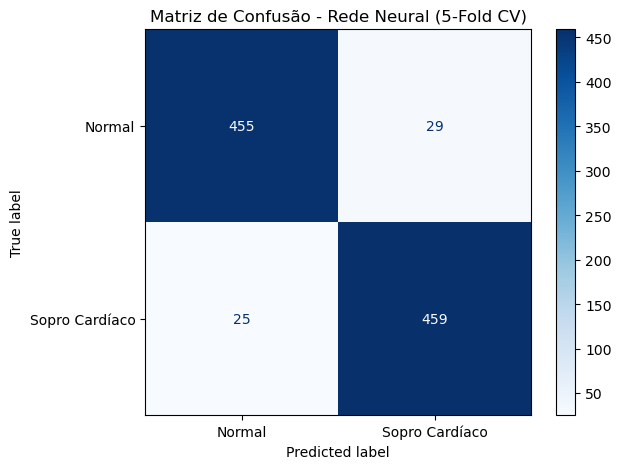


CURVAS DE APRENDIZADO


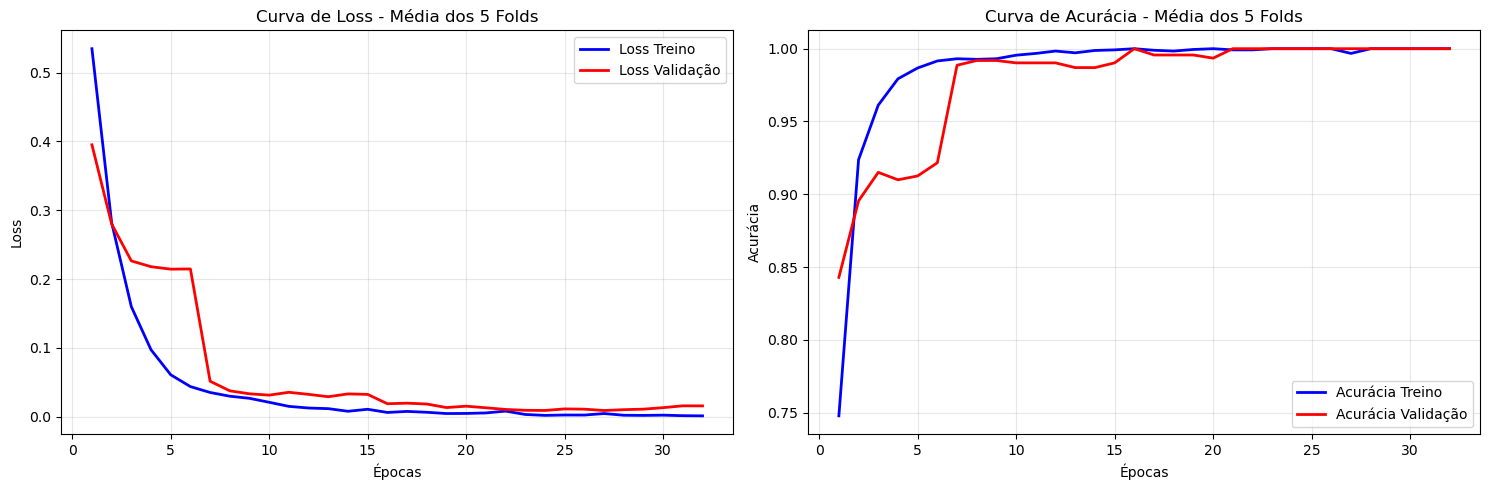


ESTATÍSTICAS DETALHADAS
Total de amostras testadas: 968
Distribuição real: [484 484]
Distribuição predita: [480 488]

Relatório de Classificação Consolidado:
                precision    recall  f1-score   support

        Normal       0.95      0.94      0.94       484
Sopro Cardíaco       0.94      0.95      0.94       484

      accuracy                           0.94       968
     macro avg       0.94      0.94      0.94       968
  weighted avg       0.94      0.94      0.94       968



In [354]:
def build_model(input_dim):
    model = Sequential([
    Dense(128, input_dim=input_dim, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
    ])
    model.compile(
        loss='binary_crossentropy',
        optimizer=Adam(learning_rate=1e-3),
        metrics=['accuracy', Precision(name='precision'), Recall(name='recall')]
    )
    return model

df = data.copy()
df = df.drop(columns=to_drop + cols_constantes, errors='ignore')

X = df.drop(columns=["Heart Sound Type", "Heart Sound ID"])
y = df["Heart Sound Type"]
groups = df["Heart Sound ID"]

cat_cols = X.select_dtypes(include='object').columns.tolist()
num_cols = X.select_dtypes(include=np.number).columns.tolist()

print("Preparando dados para SHAP...")
preprocessor_global = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

X_scaled = preprocessor_global.fit_transform(X)

if cat_cols:
    cat_feature_names = preprocessor_global.named_transformers_['cat'].get_feature_names_out(cat_cols)
    all_feature_names = list(num_cols) + list(cat_feature_names)
else:
    all_feature_names = num_cols

X_explain = pd.DataFrame(X_scaled, columns=all_feature_names)

cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
accuracies, precisions, recalls, f1s = [], [], [], []

all_y_true = []
all_y_pred = []
all_histories = []
all_models = []

print("\nIniciando cross-validation...")
for fold, (train_idx, test_idx) in enumerate(cv.split(X, y_encoded, groups)):
    print(f"\nFold {fold + 1}")

    X_train_raw, X_test_raw = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y_encoded[train_idx], y_encoded[test_idx]

    preprocessor = ColumnTransformer([
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ])
    
    X_train = preprocessor.fit_transform(X_train_raw)
    X_test = preprocessor.transform(X_test_raw)

    model = build_model(input_dim=X_train.shape[1])
    history = model.fit(
        X_train, y_train,
        validation_split=0.2,
        epochs=50,
        batch_size=32,
        callbacks=[EarlyStopping(patience=5, restore_best_weights=True)],
        verbose=0
    )

    y_pred = (model.predict(X_test).ravel() >= 0.5).astype(int)

    all_y_true.extend(y_test)
    all_y_pred.extend(y_pred)
    all_histories.append(history)
    all_models.append(model)

    acc = np.mean(y_pred == y_test)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    accuracies.append(acc)
    precisions.append(prec)
    recalls.append(rec)
    f1s.append(f1)

    print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

print("\n" + "="*60)
print("RESULTADOS FINAIS DO CROSS-VALIDATION")
print("="*60)
print(f"Acurácia média:  {np.mean(accuracies):.4f} ± {np.std(accuracies):.4f}")
print(f"Precisão média:  {np.mean(precisions):.4f} ± {np.std(precisions):.4f}")
print(f"Recall médio:    {np.mean(recalls):.4f} ± {np.std(recalls):.4f}")
print(f"F1-Score médio:  {np.mean(f1s):.4f} ± {np.std(f1s):.4f}")

print("\n" + "="*50)
print("MATRIZ DE CONFUSÃO - TODOS OS FOLDS")
print("="*50)

plt.figure(figsize=(8, 6))
cm = confusion_matrix(all_y_true, all_y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot(cmap='Blues', values_format='d')
plt.title('Matriz de Confusão - Rede Neural (5-Fold CV)')
plt.tight_layout()
plt.show()

print("\n" + "="*50)
print("CURVAS DE APRENDIZADO")
print("="*50)

max_epochs = max(len(h.history['loss']) for h in all_histories)

mean_loss = np.zeros(max_epochs)
mean_val_loss = np.zeros(max_epochs)
mean_accuracy = np.zeros(max_epochs)
mean_val_accuracy = np.zeros(max_epochs)

for epoch in range(max_epochs):
    epoch_losses = []
    epoch_val_losses = []
    epoch_accs = []
    epoch_val_accs = []
    
    for h in all_histories:
        if epoch < len(h.history['loss']):
            epoch_losses.append(h.history['loss'][epoch])
            epoch_val_losses.append(h.history['val_loss'][epoch])
            epoch_accs.append(h.history['accuracy'][epoch])
            epoch_val_accs.append(h.history['val_accuracy'][epoch])
    
    mean_loss[epoch] = np.mean(epoch_losses)
    mean_val_loss[epoch] = np.mean(epoch_val_losses)
    mean_accuracy[epoch] = np.mean(epoch_accs)
    mean_val_accuracy[epoch] = np.mean(epoch_val_accs)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))


ax1.plot(range(1, max_epochs + 1), mean_loss, 'b-', label='Loss Treino', linewidth=2)
ax1.plot(range(1, max_epochs + 1), mean_val_loss, 'r-', label='Loss Validação', linewidth=2)
ax1.set_title('Curva de Loss - Média dos 5 Folds')
ax1.set_xlabel('Épocas')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)


ax2.plot(range(1, max_epochs + 1), mean_accuracy, 'b-', label='Acurácia Treino', linewidth=2)
ax2.plot(range(1, max_epochs + 1), mean_val_accuracy, 'r-', label='Acurácia Validação', linewidth=2)
ax2.set_title('Curva de Acurácia - Média dos 5 Folds')
ax2.set_xlabel('Épocas')
ax2.set_ylabel('Acurácia')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ===== ESTATÍSTICAS DETALHADAS =====
print("\n" + "="*50)
print("ESTATÍSTICAS DETALHADAS")
print("="*50)

print(f"Total de amostras testadas: {len(all_y_true)}")
print(f"Distribuição real: {np.bincount(all_y_true)}")
print(f"Distribuição predita: {np.bincount(all_y_pred)}")

print("\nRelatório de Classificação Consolidado:")
print(classification_report(all_y_true, all_y_pred, target_names=label_encoder.classes_))
